In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
%pip install xgboost
from xgboost import XGBRegressor
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
%pip install mlflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import pickle


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
mlflow.set_tracking_uri("file:///C:/mlruns")
mlflow.set_experiment("EMI_Project")

c:\Users\Rukshana Afrin A\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///C:/mlruns/885067963678930537', creation_time=1774373648677, experiment_id='885067963678930537', last_update_time=1774373648677, lifecycle_stage='active', name='EMI_Project', tags={'mlflow.sharedViewState.ed7515db6761d944feb97e6905108cca4df71d7b4cfd544b7b9dc7649b9e30a5': 'deflate;eJxdksFu2zAMhl9l0DkY2h1zc7N0K5YUhdMFA4IhVSS6JiBLhkh18Yq8+yjbmZMe+fH/SUrkuyLQ0dT36Biimis1UyFaiHfdD+gk1swRD4mBPhPryHvGBiZRQUbNK+0IZqrPP+f0XBWrlYgcVmA64+B/+cIwvmW/1awJmM6Z3e+ZaoIFt4VIGPzkcO5TmTyJh8CBYbCL4FIjZL67HO9lE1I08CLCS7rORekj/Tq0z7gBwUZYbAiuwZc9mRCvoTYmRW26K1jdnpXyjCjTLo+t9hasmr+fBvKE3ud4Nyq+o7Xgp3iLhAd0yN1at5NtkOVHyF/cP5Sb5/3tzb78+biR/m8If9b6iA3+zaXHPYhthcTnBiNFKoyMaOVvS+i3d2FJBN9iSC3YrXYJ6MEvalmmfDHHJPkaLSyblrtr/Jo9d3ImPjk3hh+erhOHEqoIVC+9PrjMR7MLB+1W6KEvugi+wlcxqWNxRBqujxja/o48bJoQuPZA0v1muoVfWbzu9zBY1On0Dy8LAu0='}, workspace='default'>

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df=pd.read_csv("emi_prediction_dataset.csv")
df.columns=df.columns.str.strip()

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_21312\3958469766.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("emi_prediction_dataset.csv")


In [5]:
df.shape

(404800, 27)

In [6]:
df["education"].unique()

array(['Professional', 'Graduate', 'High School', 'Post Graduate', nan],
      dtype=object)

In [7]:
#gender 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [9]:
df["monthly_salary"].max()

'9999.0'

In [10]:
df.isnull().sum()

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [11]:
df.dtypes

age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object

In [12]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [13]:
df["emi_scenario"].unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)

In [14]:
df["gender"] = df["gender"].replace({
    "Female": "FEMALE",
    "female": "FEMALE",
    "F": "FEMALE",
    "FEMALE": "FEMALE",
    "Male": "MALE",
    "male": "MALE",
    "M": "MALE",
    "MALE": "MALE",

})

In [15]:
def clean_text(col):
    return col.str.lower().str.strip()

df["gender"] = clean_text(df["gender"])
df["marital_status"] = clean_text(df["marital_status"])
df["education"] = clean_text(df["education"])
df["employment_type"] = clean_text(df["employment_type"])
df["company_type"] = clean_text(df["company_type"])
df["house_type"] = clean_text(df["house_type"])
df["existing_loans"] = clean_text(df["existing_loans"])
df["emi_scenario"] = clean_text(df["emi_scenario"])

In [16]:
df["bank_balance"].dtype

dtype('O')

In [17]:
df["bank_balance"]=pd.to_numeric(df["bank_balance"],errors="coerce")

In [18]:
df[df["bank_balance"].isnull()]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
136,32.0,female,single,graduate,41500.0,private,1.1,mid-size,own,0.0,2,1,9900.0,0.0,4800.0,6900.0,7300.0,yes,9800.0,656.0,NaN,86700.0,e-commerce shopping emi,129000.0,5,Not_Eligible,980.0
298,27.0,female,married,post graduate,92400.0,private,0.5,large indian,family,0.0,5,4,10800.0,0.0,10200.0,24600.0,10000.0,yes,13200.0,677.0,NaN,275900.0,personal loan emi,935000.0,41,Not_Eligible,6608.0
691,38.0,male,married,post graduate,90800.0,government,4.3,mnc,own,0.0,3,2,6800.0,0.0,10700.0,26600.0,7900.0,no,0.0,791.0,NaN,148900.0,education emi,290000.0,15,High_Risk,25608.0
700,48.0,male,married,post graduate,114900.0,private,20.5,mnc,family,0.0,4,3,0.0,0.0,5900.0,33300.0,22300.0,no,0.0,632.0,NaN,70600.0,personal loan emi,543000.0,46,High_Risk,17088.0
818,38.0,male,married,post graduate,77800.0,private,0.7,mnc,rented,19900.0,3,2,11200.0,0.0,9100.0,12200.0,6400.0,no,0.0,740.0,NaN,79500.0,e-commerce shopping emi,104000.0,13,Not_Eligible,7600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404033,38.0,male,married,post graduate,65900.0,private,3.9,mid-size,rented,13500.0,2,1,0.0,0.0,6800.0,19700.0,6300.0,yes,12600.0,577.0,NaN,236200.0,personal loan emi,262000.0,27,Not_Eligible,2156.0
404092,48.0,female,married,professional,47400.0,private,2.5,mnc,own,0.0,2,1,0.0,0.0,5900.0,12500.0,5400.0,yes,7400.0,569.0,NaN,8900.0,vehicle emi,204000.0,68,Not_Eligible,3628.8
404336,32.0,female,married,high school,27400.0,private,0.5,large indian,family,0.0,4,3,8700.0,10200.0,1700.0,4700.0,4000.0,no,0.0,690.0,NaN,53100.0,personal loan emi,360000.0,53,Not_Eligible,500.0
404495,38.0,male,married,high school,33100.0,government,12.0,mid-size,own,0.0,3,2,4000.0,0.0,4800.0,6100.0,5000.0,no,0.0,798.0,NaN,62800.0,e-commerce shopping emi,132000.0,7,Not_Eligible,8712.0


In [19]:
df["bank_balance"].isnull().sum()
df.shape

(404800, 27)

In [20]:
df["bank_balance"].isnull().mean()*100

np.float64(1.0849802371541504)

In [21]:
dropping=df[df["bank_balance"].isnull()].index

In [22]:
df.drop(index=dropping,inplace=True)

In [23]:
df["bank_balance"].isnull().sum()

np.int64(0)

In [24]:
df["age"]=pd.to_numeric(df["age"],errors="coerce")

In [25]:
df[df["education"].isnull()]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
111,38.0,female,married,NaN,46100.0,private,3.4,mnc,own,0.0,5,4,6500.0,0.0,6300.0,12800.0,7800.0,no,0.0,730.0,308200.0,88800.0,vehicle emi,126000.0,58,Eligible,6985.0
426,38.0,female,married,NaN,15000.0,government,4.2,mnc,family,0.0,4,3,10600.0,0.0,1800.0,3800.0,2500.0,no,0.0,752.0,112200.0,55800.0,home appliances emi,280000.0,12,Not_Eligible,500.0
455,48.0,male,married,NaN,53200.0,private,3.4,small,rented,15800.0,3,2,5100.0,22000.0,6300.0,13200.0,3100.0,no,0.0,630.0,298700.0,141600.0,vehicle emi,1000000.0,54,Not_Eligible,500.0
593,48.0,female,married,NaN,42300.0,self-employed,15.6,large indian,family,0.0,3,2,5000.0,0.0,2600.0,7300.0,3200.0,no,0.0,753.0,267900.0,112000.0,home appliances emi,233000.0,20,High_Risk,14374.8
773,32.0,female,single,NaN,46100.0,private,10.0,large indian,rented,11400.0,2,1,0.0,0.0,4200.0,8400.0,6800.0,no,0.0,735.0,68800.0,38500.0,e-commerce shopping emi,141000.0,7,Not_Eligible,6120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404122,27.0,male,single,NaN,67100.0,private,1.4,mid-size,own,0.0,1,0,0.0,0.0,8900.0,11100.0,4500.0,no,0.0,747.0,77500.0,36800.0,education emi,256000.0,34,Eligible,17040.0
404308,48.0,male,married,NaN,42300.0,private,4.7,mnc,family,0.0,3,2,13900.0,0.0,3100.0,11200.0,5900.0,yes,5400.0,693.0,292900.0,80700.0,vehicle emi,937000.0,59,Not_Eligible,1078.0
404419,32.0,male,married,NaN,45100.0,government,6.6,mnc,own,0.0,3,2,12800.0,0.0,3700.0,10000.0,4300.0,no,0.0,850.0,172400.0,52400.0,vehicle emi,1493000.0,41,Not_Eligible,9438.0
404617,38.0,female,married,NaN,122300.0,private,7.7,mid-size,own,0.0,4,3,3900.0,0.0,12300.0,21400.0,15600.0,yes,12600.0,820.0,727500.0,308200.0,education emi,262000.0,12,High_Risk,23730.0


In [26]:
df["education"].unique()

array(['professional', 'graduate', 'high school', 'post graduate', nan],
      dtype=object)

In [27]:
df["education"].fillna("Graduate",inplace=True)

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_21312\668280147.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].fillna("Graduate",inplace=True)


In [28]:
df['monthly_rent'].isnull().sum()

np.int64(2394)

In [29]:
rent_median = df[df["house_type"] == "Rented"]["monthly_rent"].median()

df.loc[
    (df["monthly_rent"].isnull()) & (df["house_type"] == "Rented"),
    "monthly_rent"
] = rent_median

In [30]:
df[df['monthly_rent'].isnull()]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
116,38.0,male,married,graduate,20000.0,private,2.1,large indian,own,NaN,4,3,14800.0,20900.0,1100.0,3100.0,3700.0,no,0.0,748.0,18400.0,9500.0,vehicle emi,238000.0,69,Not_Eligible,500.0
183,48.0,male,married,post graduate,111000.0,private,1.7,large indian,rented,NaN,4,3,3800.0,0.0,11200.0,28200.0,8700.0,no,0.0,803.0,98300.0,29200.0,education emi,311000.0,24,Eligible,20160.0
226,58.0,male,married,graduate,85400.0,private,7.1,large indian,family,NaN,4,3,7100.0,0.0,6800.0,19400.0,14400.0,yes,14800.0,661.0,241900.0,59400.0,vehicle emi,103000.0,83,Eligible,8015.0
429,48.0,male,married,high school,49500.0,private,26.0,large indian,own,NaN,3,2,0.0,0.0,5500.0,10200.0,3500.0,no,0.0,690.0,123700.0,64200.0,education emi,466000.0,8,Not_Eligible,15150.0
638,27.0,male,single,graduate,34500.0,private,1.1,large indian,own,NaN,1,0,0.0,0.0,3600.0,6000.0,3500.0,no,0.0,596.0,224300.0,61900.0,home appliances emi,122000.0,17,High_Risk,9416.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404090,27.0,male,married,post graduate,35200.0,government,0.7,mid-size,rented,NaN,3,2,8000.0,0.0,3300.0,9700.0,5600.0,no,0.0,999.0,189500.0,57600.0,personal loan emi,146000.0,20,Not_Eligible,600.0
404357,48.0,male,married,graduate,33500.0,private,1.2,startup,family,NaN,3,2,0.0,15700.0,4000.0,5500.0,4000.0,no,0.0,765.0,42900.0,19000.0,e-commerce shopping emi,192000.0,23,Not_Eligible,2064.0
404541,27.0,male,single,professional,55100.0,private,0.6,large indian,rented,NaN,1,0,0.0,0.0,5900.0,13500.0,9100.0,no,0.0,843.0,300100.0,145100.0,personal loan emi,807000.0,58,Not_Eligible,6864.0
404549,48.0,male,married,graduate,54300.0,private,10.4,large indian,family,NaN,4,3,0.0,5800.0,4500.0,9000.0,4500.0,no,0.0,823.0,386000.0,206700.0,education emi,238000.0,18,Eligible,20130.0


In [31]:
df["credit_score"].isnull().sum()

np.int64(2396)

In [32]:
df[df["credit_score"].isnull()]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
154,27.0,male,married,professional,63700.0,private,4.2,mnc,own,7917.0,5,4,3400.0,0.0,8200.0,14500.0,9600.0,yes,16700.0,NaN,320700.0,173600.0,home appliances emi,103000.0,7,Not_Eligible,3955.00
619,48.0,female,married,graduate,18700.0,government,3.6,small,rented,3100.0,4,3,0.0,0.0,2600.0,4900.0,1600.0,yes,3700.0,NaN,16000.0,5200.0,vehicle emi,1468000.0,67,Not_Eligible,862.40
693,38.0,male,married,professional,30000.0,private,0.5,mnc,rented,8200.0,5,4,0.0,23900.0,4500.0,4900.0,2000.0,no,0.0,NaN,107900.0,31500.0,vehicle emi,1130000.0,19,Not_Eligible,500.00
739,38.0,male,married,post graduate,65900.0,government,1.6,mid-size,rented,11800.0,2,1,12400.0,11600.0,9100.0,12100.0,7600.0,no,0.0,NaN,353300.0,172800.0,vehicle emi,88000.0,47,Not_Eligible,650.00
796,38.0,male,married,post graduate,51900.0,private,5.8,large indian,family,0.0,4,3,0.0,6900.0,2900.0,13000.0,5600.0,no,0.0,NaN,280000.0,134200.0,home appliances emi,91000.0,21,Eligible,11750.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403813,48.0,male,married,post graduate,58200.0,private,8.1,mnc,rented,18300.0,2,1,7100.0,0.0,6200.0,10100.0,3900.0,no,0.0,NaN,169300.0,45600.0,personal loan emi,317000.0,39,Not_Eligible,6300.00
403884,38.0,female,married,professional,117200.0,private,1.7,large indian,rented,22000.0,3,2,2300.0,0.0,9500.0,22700.0,23300.0,yes,26100.0,NaN,455600.0,139000.0,personal loan emi,557000.0,32,Not_Eligible,3164.00
403936,58.0,male,married,post graduate,183300.0,private,6.6,large indian,rented,29100.0,2,1,0.0,0.0,13000.0,44200.0,27700.0,no,0.0,NaN,941600.0,234000.0,education emi,260000.0,43,Eligible,34650.00
404134,32.0,female,single,graduate,50100.0,self-employed,0.7,mnc,rented,8700.0,1,0,0.0,0.0,5600.0,10200.0,6900.0,yes,14400.0,NaN,364700.0,125400.0,personal loan emi,766000.0,40,Not_Eligible,1489.95


In [33]:
df["credit_score"].isnull().mean()*100

np.float64(0.5983896425645842)

In [34]:
df[(df["existing_loans"]=="No") & (df["credit_score"].isnull())]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi


In [35]:
median_score = df["credit_score"].median()

In [36]:
df.loc[
    (df["existing_loans"] == "Yes") & (df["credit_score"].isnull()),
    "credit_score"
] = median_score

In [37]:
df["emergency_fund"].isnull().sum()

np.int64(2324)

In [38]:
df[df["emergency_fund"].isnull()]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
237,38.0,male,married,graduate,56500.0,private,2.9,large indian,rented,11500.0,3,2,0.0,0.0,6900.0,13900.0,4100.0,no,0.0,676.0,325900.0,NaN,e-commerce shopping emi,81000.0,19,Eligible,10050.0
267,48.0,male,married,graduate,46800.0,private,0.6,large indian,family,0.0,2,1,0.0,20400.0,6100.0,13200.0,9300.0,yes,12000.0,654.0,229600.0,NaN,personal loan emi,199000.0,33,Not_Eligible,500.0
347,32.0,male,married,graduate,97500.0,private,2.2,startup,own,0.0,3,2,12900.0,0.0,9400.0,21700.0,12700.0,no,0.0,707.0,767800.0,NaN,e-commerce shopping emi,95000.0,14,Eligible,22440.0
879,48.0,female,married,graduate,36100.0,private,4.7,mnc,family,0.0,3,2,0.0,7000.0,3500.0,5900.0,2600.0,yes,7400.0,639.0,45900.0,NaN,home appliances emi,150000.0,12,Not_Eligible,2172.8
923,27.0,male,single,post graduate,67000.0,government,0.5,mnc,rented,21500.0,1,0,0.0,0.0,8000.0,10300.0,5400.0,no,0.0,705.0,347900.0,NaN,e-commerce shopping emi,164000.0,11,Not_Eligible,10900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403048,48.0,male,married,graduate,23500.0,private,0.5,large indian,rented,5200.0,2,1,10200.0,7400.0,2700.0,6300.0,2200.0,no,0.0,757.0,137900.0,NaN,education emi,314000.0,23,Not_Eligible,500.0
403349,27.0,male,single,graduate,62300.0,private,2.5,mid-size,rented,12000.0,3,2,4900.0,0.0,5500.0,14600.0,5300.0,yes,16100.0,570.0,279300.0,NaN,personal loan emi,938000.0,12,Not_Eligible,1092.0
404040,38.0,male,married,professional,114800.0,private,10.5,startup,own,0.0,3,2,11500.0,7600.0,12900.0,21000.0,8300.0,yes,23200.0,850.0,699400.0,NaN,e-commerce shopping emi,72000.0,10,Eligible,13998.6
404130,32.0,male,married,graduate,98800.0,private,3.1,large indian,own,0.0,3,2,0.0,5100.0,11400.0,17800.0,18100.0,no,0.0,744.0,106300.0,NaN,e-commerce shopping emi,104000.0,20,Eligible,18560.0


In [39]:
ratio = (df["emergency_fund"] / df["bank_balance"]).median()

In [40]:
df.loc[df["emergency_fund"].isnull(), "emergency_fund"] = \
    df["bank_balance"] * ratio

In [41]:
df.isnull().sum()

age                          3
gender                       0
marital_status               0
education                    0
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2394
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2396
bank_balance                 0
emergency_fund               0
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [42]:
df.describe()

,age,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,400405.000000,400408.000000,398014.000000,400408.000000,400408.000000,400408.000000,400408.000000,400408.000000,400408.000000,400408.000000,400408.000000,398012.000000,4.004080e+05,400408.000000,4.004080e+05,400408.000000,400408.000000
mean,38.873463,5.363445,5826.377640,2.940241,1.940241,4625.965265,4067.145012,5686.100677,12803.095093,7117.665981,4541.230695,700.845216,2.416642e+05,96748.831138,3.708620e+05,29.126366,6762.543060
std,9.301508,6.077695,8644.869453,1.075046,1.075046,5060.965105,7320.151552,3391.501532,6991.958375,4508.748571,7032.907759,88.393006,1.831964e+05,81291.587527,3.452109e+05,18.100228,7742.044156
min,26.000000,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,6.100000e+03,1400.000000,1.000000e+04,3.000000,500.000000
25%,32.000000,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,1.044000e+05,38400.000000,1.240000e+05,15.000000,500.000000
50%,38.000000,3.200000,0.000000,3.000000,2.000000,3100.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,1.959000e+05,74100.000000,2.360000e+05,25.000000,4204.200000
75%,48.000000,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7300.000000,16400.000000,9300.000000,8000.000000,748.000000,3.312000e+05,130600.000000,4.940000e+05,40.000000,9790.000000
max,59.000000,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,1.717300e+06,891500.000000,1.500000e+06,84.000000,91040.400000


In [43]:
df["monthly_salary"]=pd.to_numeric(df["monthly_salary"],errors="coerce")

In [44]:
df["monthly_salary"].isnull().sum()

np.int64(1968)

In [45]:
salary_drop=df[df["monthly_salary"].isnull()].index

In [46]:
df.drop(index=salary_drop,inplace=True)

In [47]:
df[df["monthly_salary"]>129400.0]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
7,58.0,female,married,post graduate,392044.0,private,12.9,mnc,family,0.0,4,3,0.0,0.0,5600.0,12300.0,3000.0,yes,9900.0,623.0,184600.0,61700.0,e-commerce shopping emi,153000.0,12,Not_Eligible,8260.0
35,38.0,male,married,post graduate,148600.0,private,16.0,mnc,rented,28300.0,4,3,2400.0,17400.0,11000.0,22500.0,25300.0,no,0.0,717.0,1138000.0,579000.0,vehicle emi,1055000.0,80,Eligible,22935.0
47,32.0,male,single,post graduate,158100.0,government,10.0,mnc,family,0.0,1,0,0.0,0.0,19400.0,36400.0,21700.0,no,0.0,737.0,946000.0,304200.0,education emi,137000.0,42,Eligible,44330.0
58,58.0,female,married,graduate,400172.0,private,8.6,large indian,rented,5700.0,4,3,9900.0,0.0,3600.0,5400.0,4100.0,yes,5700.0,710.0,32900.0,9700.0,personal loan emi,876000.0,37,Not_Eligible,500.0
63,38.0,male,married,post graduate,319242.0,private,0.5,mnc,rented,9600.0,2,1,12500.0,0.0,2800.0,7500.0,6000.0,no,0.0,704.0,224300.0,106300.0,e-commerce shopping emi,23000.0,20,Not_Eligible,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404519,38.0,male,married,professional,150500.0,private,0.8,startup,rented,24800.0,4,3,2400.0,18300.0,18700.0,44300.0,19700.0,yes,39400.0,695.0,480800.0,114300.0,vehicle emi,1305000.0,48,Not_Eligible,500.0
404614,27.0,female,single,post graduate,130300.0,private,2.5,startup,rented,27000.0,1,0,0.0,0.0,8500.0,29600.0,18400.0,no,0.0,757.0,884400.0,362300.0,e-commerce shopping emi,89000.0,15,Eligible,30888.0
404663,38.0,male,married,post graduate,175400.0,government,10.2,mid-size,own,0.0,3,2,11600.0,0.0,18200.0,47800.0,21900.0,yes,33700.0,698.0,1019200.0,574900.0,personal loan emi,425000.0,38,High_Risk,16247.0
404754,48.0,female,single,post graduate,144900.0,private,2.5,large indian,own,0.0,1,0,0.0,0.0,7400.0,42200.0,7500.0,no,0.0,764.0,334600.0,79400.0,home appliances emi,158000.0,32,Eligible,52680.0


In [48]:
df[(df["monthly_salary"]>129400.0) & (df["years_of_employment"]< 3.0)]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
63,38.0,male,married,post graduate,319242.0,private,0.5,mnc,rented,9600.0,2,1,12500.0,0.0,2800.0,7500.0,6000.0,no,0.0,704.0,224300.0,106300.0,e-commerce shopping emi,23000.0,20,Not_Eligible,500.0
100,27.0,male,single,professional,166700.0,self-employed,2.6,startup,family,0.0,3,2,0.0,0.0,16600.0,29000.0,29100.0,no,0.0,654.0,809600.0,414500.0,e-commerce shopping emi,184000.0,11,Eligible,41400.0
138,38.0,female,single,graduate,139000.0,private,2.6,mnc,rented,33000.0,1,0,0.0,0.0,19100.0,32600.0,12300.0,yes,36700.0,719.0,185400.0,70600.0,home appliances emi,234000.0,21,Not_Eligible,1484.0
266,38.0,male,married,professional,153100.0,government,0.7,mid-size,rented,48900.0,4,3,7100.0,0.0,16600.0,31600.0,27400.0,yes,31200.0,701.0,889000.0,349800.0,home appliances emi,26000.0,10,Not_Eligible,500.0
290,32.0,male,single,professional,143300.0,private,0.5,startup,rented,35800.0,2,1,5100.0,0.0,13800.0,24500.0,12800.0,yes,21200.0,999.0,722800.0,225400.0,home appliances emi,22000.0,25,Eligible,10113.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404474,27.0,male,single,professional,133100.0,private,1.4,mid-size,rented,28100.0,2,1,0.0,0.0,15800.0,32700.0,26500.0,yes,17800.0,567.0,207200.0,99000.0,education emi,472000.0,33,Not_Eligible,2732.8
404519,38.0,male,married,professional,150500.0,private,0.8,startup,rented,24800.0,4,3,2400.0,18300.0,18700.0,44300.0,19700.0,yes,39400.0,695.0,480800.0,114300.0,vehicle emi,1305000.0,48,Not_Eligible,500.0
404614,27.0,female,single,post graduate,130300.0,private,2.5,startup,rented,27000.0,1,0,0.0,0.0,8500.0,29600.0,18400.0,no,0.0,757.0,884400.0,362300.0,e-commerce shopping emi,89000.0,15,Eligible,30888.0
404754,48.0,female,single,post graduate,144900.0,private,2.5,large indian,own,0.0,1,0,0.0,0.0,7400.0,42200.0,7500.0,no,0.0,764.0,334600.0,79400.0,home appliances emi,158000.0,32,Eligible,52680.0


In [49]:
df["suspicious_salary"] = (
    (df["monthly_salary"] > 129000) &
    (df["years_of_employment"] < 2)
)

In [50]:
df[df["suspicious_salary"]==True].head(10)

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary
9,32.0,female,single,post graduate,129200.0,private,1.9,mnc,family,0.0,2,1,8100.0,11300.0,11800.0,24100.0,16500.0,yes,33100.0,681.0,963200.0,519100.0,e-commerce shopping emi,81000.0,3,Not_Eligible,9355.5,True
63,38.0,male,married,post graduate,319242.0,private,0.5,mnc,rented,9600.0,2,1,12500.0,0.0,2800.0,7500.0,6000.0,no,0.0,704.0,224300.0,106300.0,e-commerce shopping emi,23000.0,20,Not_Eligible,500.0,True
266,38.0,male,married,professional,153100.0,government,0.7,mid-size,rented,48900.0,4,3,7100.0,0.0,16600.0,31600.0,27400.0,yes,31200.0,701.0,889000.0,349800.0,home appliances emi,26000.0,10,Not_Eligible,500.0,True
290,32.0,male,single,professional,143300.0,private,0.5,startup,rented,35800.0,2,1,5100.0,0.0,13800.0,24500.0,12800.0,yes,21200.0,999.0,722800.0,225400.0,home appliances emi,22000.0,25,Eligible,10113.6,True
376,38.0,male,married,professional,165900.0,self-employed,0.5,mid-size,family,0.0,3,2,13400.0,0.0,10900.0,40500.0,15900.0,no,0.0,750.0,968100.0,395000.0,education emi,238000.0,30,Eligible,46008.0,True
480,48.0,female,married,professional,155800.0,self-employed,1.0,startup,rented,24600.0,4,3,2800.0,0.0,19500.0,27300.0,11700.0,no,0.0,730.0,175600.0,49100.0,personal loan emi,830000.0,17,Not_Eligible,25164.0,True
621,38.0,male,married,professional,170800.0,government,1.8,large indian,family,0.0,4,3,0.0,8100.0,23300.0,31500.0,27800.0,yes,24300.0,692.0,429000.0,132900.0,education emi,434000.0,28,High_Risk,19530.0,True
854,38.0,male,married,professional,150900.0,self-employed,0.5,large indian,own,21906.0,2,1,9800.0,0.0,8200.0,37500.0,21400.0,no,0.0,737.0,296600.0,145700.0,vehicle emi,1462000.0,20,Not_Eligible,26640.0,True
864,48.0,male,married,post graduate,137600.0,private,1.6,mid-size,own,0.0,2,1,11700.0,0.0,8800.0,31800.0,23200.0,no,0.0,704.0,531700.0,304800.0,e-commerce shopping emi,184000.0,10,Eligible,31050.0,True
872,27.0,male,single,professional,170500.0,private,1.4,large indian,rented,50600.0,2,1,4200.0,0.0,8800.0,30100.0,17800.0,yes,34000.0,599.0,738900.0,305000.0,home appliances emi,126000.0,34,Eligible,7000.0,True


In [51]:
# Salary anomaly (high salary, low experience)
df["salary_anomaly"] = (df["monthly_salary"] > 200000) & (df["years_of_employment"] < 1)

# Family mismatch
df["family_mismatch"] = df["family_size"] != (df["dependents"] + 1)

# Expense mismatch (no dependents but school fees present)
df["expense_mismatch"] = (df["dependents"] == 0) & (df["school_fees"] > 0)

In [52]:
df[["salary_anomaly", "family_mismatch", "expense_mismatch"]].sum()

salary_anomaly      751
family_mismatch       0
expense_mismatch      0
dtype: int64

In [53]:
df[df["salary_anomaly"]==True]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch
63,38.0,male,married,post graduate,319242.0,private,0.5,mnc,rented,9600.0,2,1,12500.0,0.0,2800.0,7500.0,6000.0,no,0.0,704.0,224300.0,106300.0,e-commerce shopping emi,23000.0,20,Not_Eligible,500.00,True,True,False,False
1804,27.0,female,single,graduate,392291.0,private,0.5,mnc,rented,5400.0,1,0,0.0,0.0,3100.0,4800.0,2800.0,yes,6300.0,534.0,56600.0,22700.0,education emi,68000.0,29,Not_Eligible,500.00,True,True,False,False
2745,32.0,male,married,post graduate,496868.0,private,0.5,mid-size,own,0.0,4,3,0.0,0.0,7900.0,27100.0,6400.0,no,0.0,663.0,715500.0,303800.0,e-commerce shopping emi,126000.0,15,Eligible,32720.00,True,True,False,False
3366,38.0,male,married,post graduate,348732.0,private,0.5,large indian,own,0.0,4,3,0.0,0.0,7800.0,16400.0,7300.0,yes,7900.0,632.0,405200.0,140200.0,e-commerce shopping emi,143000.0,6,Not_Eligible,5026.56,True,True,False,False
3884,32.0,female,married,high school,415441.0,private,0.5,large indian,rented,15400.0,3,2,7200.0,9700.0,4700.0,10300.0,5100.0,no,0.0,646.0,178900.0,49400.0,vehicle emi,121000.0,28,Not_Eligible,500.00,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402368,27.0,male,married,professional,207000.0,government,0.6,startup,rented,61400.0,3,2,13000.0,0.0,25500.0,42100.0,37900.0,no,0.0,850.0,1556600.0,711600.0,home appliances emi,27000.0,36,Eligible,17886.00,True,True,False,False
402801,58.0,male,married,post graduate,429998.0,private,0.9,large indian,rented,19700.0,4,3,3700.0,5200.0,9800.0,25100.0,11700.0,no,0.0,742.0,774800.0,294300.0,education emi,453000.0,9,Not_Eligible,11748.00,True,True,False,False
403509,32.0,female,married,post graduate,384552.0,private,0.5,startup,own,0.0,3,2,0.0,0.0,4700.0,19400.0,7700.0,no,0.0,690.0,347000.0,149900.0,vehicle emi,1489000.0,52,Not_Eligible,18200.00,True,True,False,False
403711,32.0,male,married,graduate,456130.0,government,0.5,mid-size,family,0.0,4,3,0.0,0.0,4300.0,10800.0,3400.0,yes,10500.0,564.0,248500.0,120800.0,personal loan emi,248000.0,43,Not_Eligible,6048.00,True,True,False,False


In [54]:
high_salary_low_exp = df[
    (df["monthly_salary"] > 200000) &
    (df["years_of_employment"] < 1)
]

In [55]:
df["high_salary_low_exp"] = (
    (df["monthly_salary"] > 200000) &
    (df["years_of_employment"] < 1)
)

In [56]:
df[df["high_salary_low_exp"] ]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp
63,38.0,male,married,post graduate,319242.0,private,0.5,mnc,rented,9600.0,2,1,12500.0,0.0,2800.0,7500.0,6000.0,no,0.0,704.0,224300.0,106300.0,e-commerce shopping emi,23000.0,20,Not_Eligible,500.00,True,True,False,False,True
1804,27.0,female,single,graduate,392291.0,private,0.5,mnc,rented,5400.0,1,0,0.0,0.0,3100.0,4800.0,2800.0,yes,6300.0,534.0,56600.0,22700.0,education emi,68000.0,29,Not_Eligible,500.00,True,True,False,False,True
2745,32.0,male,married,post graduate,496868.0,private,0.5,mid-size,own,0.0,4,3,0.0,0.0,7900.0,27100.0,6400.0,no,0.0,663.0,715500.0,303800.0,e-commerce shopping emi,126000.0,15,Eligible,32720.00,True,True,False,False,True
3366,38.0,male,married,post graduate,348732.0,private,0.5,large indian,own,0.0,4,3,0.0,0.0,7800.0,16400.0,7300.0,yes,7900.0,632.0,405200.0,140200.0,e-commerce shopping emi,143000.0,6,Not_Eligible,5026.56,True,True,False,False,True
3884,32.0,female,married,high school,415441.0,private,0.5,large indian,rented,15400.0,3,2,7200.0,9700.0,4700.0,10300.0,5100.0,no,0.0,646.0,178900.0,49400.0,vehicle emi,121000.0,28,Not_Eligible,500.00,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402368,27.0,male,married,professional,207000.0,government,0.6,startup,rented,61400.0,3,2,13000.0,0.0,25500.0,42100.0,37900.0,no,0.0,850.0,1556600.0,711600.0,home appliances emi,27000.0,36,Eligible,17886.00,True,True,False,False,True
402801,58.0,male,married,post graduate,429998.0,private,0.9,large indian,rented,19700.0,4,3,3700.0,5200.0,9800.0,25100.0,11700.0,no,0.0,742.0,774800.0,294300.0,education emi,453000.0,9,Not_Eligible,11748.00,True,True,False,False,True
403509,32.0,female,married,post graduate,384552.0,private,0.5,startup,own,0.0,3,2,0.0,0.0,4700.0,19400.0,7700.0,no,0.0,690.0,347000.0,149900.0,vehicle emi,1489000.0,52,Not_Eligible,18200.00,True,True,False,False,True
403711,32.0,male,married,graduate,456130.0,government,0.5,mid-size,family,0.0,4,3,0.0,0.0,4300.0,10800.0,3400.0,yes,10500.0,564.0,248500.0,120800.0,personal loan emi,248000.0,43,Not_Eligible,6048.00,True,True,False,False,True


In [57]:
df["late_high_salary_low_exp"] = (
    (df["age"] > 35) &
    (df["years_of_employment"] < 1) &
    (df["monthly_salary"] > 200000)
)

In [58]:
df[df["late_high_salary_low_exp"]]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp
63,38.0,male,married,post graduate,319242.0,private,0.5,mnc,rented,9600.0,2,1,12500.0,0.0,2800.0,7500.0,6000.0,no,0.0,704.0,224300.0,106300.0,e-commerce shopping emi,23000.0,20,Not_Eligible,500.00,True,True,False,False,True,True
3366,38.0,male,married,post graduate,348732.0,private,0.5,large indian,own,0.0,4,3,0.0,0.0,7800.0,16400.0,7300.0,yes,7900.0,632.0,405200.0,140200.0,e-commerce shopping emi,143000.0,6,Not_Eligible,5026.56,True,True,False,False,True,True
4324,38.0,female,married,professional,442650.0,self-employed,0.8,startup,own,0.0,4,3,0.0,0.0,9900.0,19800.0,6600.0,yes,8500.0,621.0,90200.0,43500.0,vehicle emi,527000.0,49,Not_Eligible,5342.40,True,True,False,False,True,True
4783,38.0,female,married,professional,355703.0,private,0.6,large indian,family,0.0,3,2,5700.0,12700.0,3400.0,12700.0,3100.0,no,0.0,NaN,154000.0,40400.0,home appliances emi,76000.0,23,Eligible,8160.00,True,True,False,False,True,True
5159,48.0,female,single,high school,351922.0,private,0.5,mnc,own,0.0,2,1,2000.0,0.0,2000.0,5100.0,1900.0,yes,8000.0,652.0,28500.0,16700.0,home appliances emi,230000.0,33,Not_Eligible,2464.00,True,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393339,38.0,male,married,high school,339080.0,private,0.9,startup,rented,5200.0,5,4,14000.0,5600.0,800.0,2600.0,3100.0,yes,1900.0,698.0,100400.0,60200.0,vehicle emi,1117000.0,44,Not_Eligible,500.00,True,True,False,False,True,True
393470,38.0,male,single,post graduate,338387.0,self-employed,0.5,mid-size,rented,18800.0,2,1,9200.0,0.0,6000.0,11200.0,8700.0,yes,15600.0,560.0,453500.0,146600.0,education emi,55000.0,16,Not_Eligible,500.00,True,True,False,False,True,True
400245,38.0,male,married,high school,328417.0,government,0.5,large indian,own,0.0,3,2,0.0,0.0,8800.0,26600.0,10400.0,no,0.0,662.0,247000.0,142200.0,home appliances emi,83000.0,22,Eligible,24300.00,True,True,False,False,True,True
402026,38.0,male,married,graduate,489664.0,government,0.6,mid-size,family,0.0,2,1,0.0,0.0,7900.0,9300.0,5200.0,no,0.0,675.0,321400.0,173700.0,e-commerce shopping emi,149000.0,22,Eligible,17900.00,True,True,False,False,True,True


In [59]:
df["strong_error"] = (
    (df["age"] > 40) &
    (df["years_of_employment"] < 1) &
    (df["monthly_salary"] > 200000) &
    (df["education"] == "High School")
)

In [60]:
df[df["strong_error"]]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error


In [61]:
df = df[df["strong_error"] == False]

In [62]:
df.shape

(398440, 34)

In [63]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error
0,38.0,female,married,professional,82600.0,private,0.9,mid-size,rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,yes,23700.0,660.0,303200.0,70200.0,personal loan emi,850000.0,15,Not_Eligible,500.0,False,False,False,False,False,False,False
1,38.0,female,married,graduate,21500.0,private,7.0,mnc,family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,yes,4100.0,714.0,92500.0,26900.0,e-commerce shopping emi,128000.0,19,Not_Eligible,700.0,False,False,False,False,False,False,False
2,38.0,male,married,professional,86100.0,private,5.8,startup,own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,no,0.0,650.0,672100.0,324200.0,education emi,306000.0,16,Eligible,27775.0,False,False,False,False,False,False,False
3,58.0,female,married,high school,66800.0,private,2.2,mid-size,own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,no,0.0,685.0,440900.0,178100.0,vehicle emi,304000.0,83,Eligible,16170.0,False,False,False,False,False,False,False
4,48.0,female,married,professional,57300.0,private,3.4,mid-size,family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,no,0.0,770.0,97300.0,28200.0,home appliances emi,252000.0,7,Not_Eligible,500.0,False,False,False,False,False,False,False


In [64]:
df["years_of_employment"].max()

36.0

In [65]:
df[(df["years_of_employment"]>30) &(df["age"]==58)]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error
6,58.0,male,single,high school,27100.0,private,36.0,large indian,own,0.0,3,2,10200.0,0.0,1600.0,7300.0,4100.0,no,0.0,741.0,68000.0,36200.0,home appliances emi,280000.0,11,Not_Eligible,1950.0,False,False,False,False,False,False,False
8,58.0,female,married,professional,47700.0,private,36.0,large indian,family,0.0,3,2,15000.0,0.0,6100.0,7300.0,8300.0,no,0.0,712.0,235600.0,81800.0,e-commerce shopping emi,106000.0,14,Not_Eligible,5500.0,False,False,False,False,False,False,False
98,58.0,male,married,post graduate,113300.0,private,36.0,large indian,rented,21800.0,3,2,11600.0,15500.0,13700.0,31700.0,16500.0,no,0.0,846.0,317200.0,103300.0,home appliances emi,208000.0,15,Not_Eligible,1500.0,False,False,False,False,False,False,False
177,58.0,male,married,high school,26400.0,private,36.0,mid-size,rented,5200.0,3,2,0.0,10700.0,1900.0,6400.0,3200.0,no,0.0,668.0,94500.0,35600.0,e-commerce shopping emi,112000.0,23,Not_Eligible,500.0,False,False,False,False,False,False,False
188,58.0,male,married,graduate,48300.0,private,36.0,mid-size,own,0.0,3,2,0.0,0.0,4200.0,14000.0,8300.0,no,0.0,736.0,250600.0,70600.0,home appliances emi,149000.0,33,Eligible,10900.0,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404409,58.0,male,married,post graduate,101600.0,private,36.0,mnc,rented,27800.0,2,1,0.0,0.0,9000.0,30000.0,9700.0,yes,11300.0,824.0,626200.0,287700.0,personal loan emi,931000.0,23,Not_Eligible,6375.6,False,False,False,False,False,False,False
404424,58.0,female,married,post graduate,61400.0,private,33.8,mid-size,family,0.0,3,2,7700.0,0.0,6200.0,11100.0,7200.0,yes,8000.0,560.0,432000.0,151700.0,e-commerce shopping emi,92000.0,6,Not_Eligible,6529.6,False,False,False,False,False,False,False
404475,58.0,male,married,high school,41400.0,private,36.0,mid-size,rented,8500.0,5,4,0.0,0.0,2300.0,10700.0,2800.0,no,0.0,710.0,68600.0,24300.0,vehicle emi,1146000.0,63,Not_Eligible,6840.0,False,False,False,False,False,False,False
404555,58.0,male,married,graduate,36300.0,private,32.0,mnc,rented,6300.0,4,3,9200.0,14800.0,2400.0,5900.0,2400.0,no,0.0,728.0,279600.0,141900.0,personal loan emi,797000.0,31,Not_Eligible,500.0,False,False,False,False,False,False,False


Rent outlier

In [66]:
Q1 = df["monthly_rent"].quantile(0.25)
Q3 = df["monthly_rent"].quantile(0.75)

In [67]:
IQR = Q3 - Q1

In [68]:
upper_whisker = Q3 + 1.5 * IQR
upper_whisker

np.float64(26500.0)

In [69]:
df[df["monthly_rent"] > upper_whisker]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error
35,38.0,male,married,post graduate,148600.0,private,16.0,mnc,rented,28300.0,4,3,2400.0,17400.0,11000.0,22500.0,25300.0,no,0.0,717.0,1138000.0,579000.0,vehicle emi,1055000.0,80,Eligible,22935.0,False,False,False,False,False,False,False
49,47.0,male,married,graduate,93257.0,self-employed,3.4,mid-size,rented,29500.0,2,1,10600.0,0.0,9300.0,22700.0,13000.0,no,0.0,718.0,291300.0,129400.0,vehicle emi,316000.0,57,Not_Eligible,4275.0,False,False,False,False,False,False,False
57,32.0,female,married,high school,92200.0,government,0.6,mnc,rented,27800.0,4,3,0.0,0.0,12500.0,18000.0,12400.0,yes,20700.0,798.0,357800.0,153600.0,personal loan emi,104000.0,20,Not_Eligible,500.0,False,False,False,False,False,False,False
94,48.0,female,married,post graduate,125200.0,government,1.5,mnc,rented,36500.0,3,2,11200.0,18000.0,8400.0,29100.0,11100.0,no,0.0,770.0,976700.0,208600.0,personal loan emi,350000.0,53,Not_Eligible,7194.0,False,False,False,False,False,False,False
138,38.0,female,single,graduate,139000.0,private,2.6,mnc,rented,33000.0,1,0,0.0,0.0,19100.0,32600.0,12300.0,yes,36700.0,719.0,185400.0,70600.0,home appliances emi,234000.0,21,Not_Eligible,1484.0,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404636,38.0,male,married,graduate,91300.0,private,11.9,mnc,rented,30800.0,5,4,0.0,0.0,10200.0,17300.0,16200.0,yes,10900.0,643.0,79100.0,16400.0,home appliances emi,110000.0,13,Not_Eligible,1321.6,False,False,False,False,False,False,False
404681,48.0,male,single,professional,109700.0,private,4.9,mnc,rented,32200.0,1,0,0.0,0.0,11000.0,17400.0,16400.0,yes,18000.0,696.0,678600.0,219900.0,personal loan emi,610000.0,14,Not_Eligible,5659.5,False,False,False,False,False,False,False
404757,48.0,male,married,professional,148800.0,government,0.9,mnc,rented,45000.0,2,1,13900.0,0.0,20500.0,23000.0,28500.0,yes,19900.0,774.0,121000.0,41100.0,e-commerce shopping emi,198000.0,10,Not_Eligible,500.0,True,False,False,False,False,False,False
404761,48.0,male,married,post graduate,96800.0,self-employed,3.1,large indian,rented,32900.0,4,3,0.0,12300.0,9900.0,26100.0,17400.0,no,0.0,635.0,174100.0,66000.0,personal loan emi,320000.0,18,Not_Eligible,500.0,False,False,False,False,False,False,False


In [70]:
df["rent_outlier"] = df["monthly_rent"] > upper_whisker

In [71]:
df["rent_outlier"].sum()

np.int64(12489)

In [72]:
df[
    (df["monthly_rent"] > upper_whisker) &
    (df["monthly_rent"] > df["monthly_salary"] * 0.6)
]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier
404,27.0,female,single,professional,8727.0,private,3.8,mid-size,rented,38400.0,1,0,0.0,0.0,21400.0,26600.0,27500.0,no,0.0,801.0,912500.0,423800.0,home appliances emi,264000.0,23,Eligible,22704.0,False,False,False,False,False,False,False,True
2408,58.0,female,married,post graduate,7240.0,private,0.6,mnc,rented,29000.0,4,3,0.0,19300.0,10200.0,22000.0,14800.0,no,0.0,754.0,675000.0,257100.0,education emi,85000.0,46,Eligible,19536.0,False,False,False,False,False,False,False,True
7351,27.0,male,single,graduate,10553.0,private,1.9,mid-size,rented,26800.0,2,1,0.0,0.0,4200.0,23600.0,8600.0,no,0.0,753.0,519000.0,275500.0,vehicle emi,819000.0,22,Not_Eligible,13464.0,False,False,False,False,False,False,False,True
12599,48.0,male,single,post graduate,8401.0,private,3.4,mid-size,rented,29500.0,1,0,0.0,0.0,11000.0,32400.0,14200.0,no,0.0,827.0,180600.0,85600.0,personal loan emi,80000.0,58,Eligible,22512.0,False,False,False,False,False,False,False,True
12811,27.0,male,single,professional,9346.0,private,0.7,large indian,rented,52600.0,1,0,0.0,0.0,18000.0,41400.0,20500.0,yes,32900.0,835.0,493200.0,161400.0,vehicle emi,1357000.0,83,Not_Eligible,500.0,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399648,32.0,male,single,professional,7701.0,private,2.6,mid-size,rented,35200.0,1,0,0.0,0.0,9600.0,24800.0,19200.0,no,0.0,675.0,310500.0,164600.0,personal loan emi,158000.0,30,Not_Eligible,6400.0,False,False,False,False,False,False,False,True
400091,48.0,female,married,high school,10648.0,private,1.9,startup,rented,27700.0,4,3,7900.0,0.0,10200.0,23000.0,8200.0,yes,9200.0,679.0,172700.0,58800.0,home appliances emi,119000.0,6,Not_Eligible,500.0,False,False,False,False,False,False,False,True
402454,32.0,male,single,graduate,9769.0,private,5.0,small,rented,32700.0,2,1,12500.0,5800.0,14600.0,21800.0,11500.0,no,0.0,715.0,413600.0,159000.0,education emi,147000.0,9,Not_Eligible,500.0,False,False,False,False,False,False,False,True
403238,32.0,female,single,professional,7275.0,private,1.2,mid-size,rented,34400.0,2,1,6800.0,0.0,10000.0,20200.0,6400.0,no,0.0,734.0,528300.0,151700.0,vehicle emi,262000.0,33,Eligible,22800.0,False,False,False,False,False,False,False,True


In [73]:
df["strong_rent_error"] = (
    (df["monthly_rent"] > upper_whisker) &
    (df["monthly_rent"] > df["monthly_salary"])
)

In [74]:
df[df["strong_rent_error"]]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error
404,27.0,female,single,professional,8727.0,private,3.8,mid-size,rented,38400.0,1,0,0.0,0.0,21400.0,26600.0,27500.0,no,0.0,801.0,912500.0,423800.0,home appliances emi,264000.0,23,Eligible,22704.0,False,False,False,False,False,False,False,True,True
2408,58.0,female,married,post graduate,7240.0,private,0.6,mnc,rented,29000.0,4,3,0.0,19300.0,10200.0,22000.0,14800.0,no,0.0,754.0,675000.0,257100.0,education emi,85000.0,46,Eligible,19536.0,False,False,False,False,False,False,False,True,True
7351,27.0,male,single,graduate,10553.0,private,1.9,mid-size,rented,26800.0,2,1,0.0,0.0,4200.0,23600.0,8600.0,no,0.0,753.0,519000.0,275500.0,vehicle emi,819000.0,22,Not_Eligible,13464.0,False,False,False,False,False,False,False,True,True
12599,48.0,male,single,post graduate,8401.0,private,3.4,mid-size,rented,29500.0,1,0,0.0,0.0,11000.0,32400.0,14200.0,no,0.0,827.0,180600.0,85600.0,personal loan emi,80000.0,58,Eligible,22512.0,False,False,False,False,False,False,False,True,True
12811,27.0,male,single,professional,9346.0,private,0.7,large indian,rented,52600.0,1,0,0.0,0.0,18000.0,41400.0,20500.0,yes,32900.0,835.0,493200.0,161400.0,vehicle emi,1357000.0,83,Not_Eligible,500.0,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399648,32.0,male,single,professional,7701.0,private,2.6,mid-size,rented,35200.0,1,0,0.0,0.0,9600.0,24800.0,19200.0,no,0.0,675.0,310500.0,164600.0,personal loan emi,158000.0,30,Not_Eligible,6400.0,False,False,False,False,False,False,False,True,True
400091,48.0,female,married,high school,10648.0,private,1.9,startup,rented,27700.0,4,3,7900.0,0.0,10200.0,23000.0,8200.0,yes,9200.0,679.0,172700.0,58800.0,home appliances emi,119000.0,6,Not_Eligible,500.0,False,False,False,False,False,False,False,True,True
402454,32.0,male,single,graduate,9769.0,private,5.0,small,rented,32700.0,2,1,12500.0,5800.0,14600.0,21800.0,11500.0,no,0.0,715.0,413600.0,159000.0,education emi,147000.0,9,Not_Eligible,500.0,False,False,False,False,False,False,False,True,True
403238,32.0,female,single,professional,7275.0,private,1.2,mid-size,rented,34400.0,2,1,6800.0,0.0,10000.0,20200.0,6400.0,no,0.0,734.0,528300.0,151700.0,vehicle emi,262000.0,33,Eligible,22800.0,False,False,False,False,False,False,False,True,True


In [75]:
df["strong_rent_error"].sum()

np.int64(123)

In [76]:
df = df[~df["strong_rent_error"]]

In [77]:
df["rent_outlier"] = df["monthly_rent"] > upper_whisker

In [78]:
df[df["rent_outlier"]]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error
35,38.0,male,married,post graduate,148600.0,private,16.0,mnc,rented,28300.0,4,3,2400.0,17400.0,11000.0,22500.0,25300.0,no,0.0,717.0,1138000.0,579000.0,vehicle emi,1055000.0,80,Eligible,22935.0,False,False,False,False,False,False,False,True,False
49,47.0,male,married,graduate,93257.0,self-employed,3.4,mid-size,rented,29500.0,2,1,10600.0,0.0,9300.0,22700.0,13000.0,no,0.0,718.0,291300.0,129400.0,vehicle emi,316000.0,57,Not_Eligible,4275.0,False,False,False,False,False,False,False,True,False
57,32.0,female,married,high school,92200.0,government,0.6,mnc,rented,27800.0,4,3,0.0,0.0,12500.0,18000.0,12400.0,yes,20700.0,798.0,357800.0,153600.0,personal loan emi,104000.0,20,Not_Eligible,500.0,False,False,False,False,False,False,False,True,False
94,48.0,female,married,post graduate,125200.0,government,1.5,mnc,rented,36500.0,3,2,11200.0,18000.0,8400.0,29100.0,11100.0,no,0.0,770.0,976700.0,208600.0,personal loan emi,350000.0,53,Not_Eligible,7194.0,False,False,False,False,False,False,False,True,False
138,38.0,female,single,graduate,139000.0,private,2.6,mnc,rented,33000.0,1,0,0.0,0.0,19100.0,32600.0,12300.0,yes,36700.0,719.0,185400.0,70600.0,home appliances emi,234000.0,21,Not_Eligible,1484.0,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404636,38.0,male,married,graduate,91300.0,private,11.9,mnc,rented,30800.0,5,4,0.0,0.0,10200.0,17300.0,16200.0,yes,10900.0,643.0,79100.0,16400.0,home appliances emi,110000.0,13,Not_Eligible,1321.6,False,False,False,False,False,False,False,True,False
404681,48.0,male,single,professional,109700.0,private,4.9,mnc,rented,32200.0,1,0,0.0,0.0,11000.0,17400.0,16400.0,yes,18000.0,696.0,678600.0,219900.0,personal loan emi,610000.0,14,Not_Eligible,5659.5,False,False,False,False,False,False,False,True,False
404757,48.0,male,married,professional,148800.0,government,0.9,mnc,rented,45000.0,2,1,13900.0,0.0,20500.0,23000.0,28500.0,yes,19900.0,774.0,121000.0,41100.0,e-commerce shopping emi,198000.0,10,Not_Eligible,500.0,True,False,False,False,False,False,False,True,False
404761,48.0,male,married,post graduate,96800.0,self-employed,3.1,large indian,rented,32900.0,4,3,0.0,12300.0,9900.0,26100.0,17400.0,no,0.0,635.0,174100.0,66000.0,personal loan emi,320000.0,18,Not_Eligible,500.0,False,False,False,False,False,False,False,True,False


In [79]:
df["rent_to_salary_ratio"] = df["monthly_rent"] / df["monthly_salary"]

In [80]:
df["rent_to_salary_ratio"]

0         0.242131
1         0.000000
2         0.000000
3         0.000000
4         0.000000
            ...   
404795    0.320988
404796    0.000000
404797    0.245136
404798    0.000000
404799    0.000000
Name: rent_to_salary_ratio, Length: 398317, dtype: float64

In [81]:
df[["monthly_salary", "monthly_rent", "rent_to_salary_ratio"]]

,monthly_salary,monthly_rent,rent_to_salary_ratio
0,82600.0,20000.0,0.242131
1,21500.0,0.0,0.000000
2,86100.0,0.0,0.000000
3,66800.0,0.0,0.000000
4,57300.0,0.0,0.000000
...,...,...,...
404795,32400.0,10400.0,0.320988
404796,49200.0,0.0,0.000000
404797,25700.0,6300.0,0.245136
404798,47200.0,0.0,0.000000


In [82]:
df[df["rent_to_salary_ratio"] > 1]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio
224,32.0,male,married,high school,5644.0,private,5.5,large indian,own,6982.0,4,3,14700.0,19600.0,4400.0,21200.0,4600.0,no,0.0,676.0,292800.0,92400.0,education emi,160000.0,30,High_Risk,6800.0,False,False,False,False,False,False,False,False,False,1.237066
556,32.0,male,single,graduate,11852.0,self-employed,6.0,mnc,rented,24000.0,3,2,4700.0,0.0,7900.0,17500.0,10200.0,yes,12900.0,688.0,482300.0,225200.0,education emi,250000.0,9,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,2.024975
714,27.0,male,single,professional,8040.0,self-employed,1.0,large indian,rented,24900.0,2,1,0.0,0.0,10100.0,26400.0,17600.0,yes,29400.0,694.0,742800.0,236900.0,personal loan emi,61000.0,20,Eligible,8473.5,False,False,False,False,False,False,False,False,False,3.097015
1373,32.0,male,married,post graduate,9451.0,government,1.1,large indian,rented,11600.0,5,4,0.0,0.0,6400.0,7900.0,7500.0,no,0.0,999.0,208000.0,103700.0,home appliances emi,287000.0,32,Not_Eligible,9000.0,False,False,False,False,False,False,False,False,False,1.227383
1656,48.0,male,married,graduate,9843.0,private,20.1,large indian,rented,21500.0,4,3,0.0,0.0,4300.0,21200.0,12400.0,yes,11000.0,752.0,577000.0,271500.0,vehicle emi,447000.0,25,Not_Eligible,3187.8,False,False,False,False,False,False,False,False,False,2.184293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401127,32.0,female,married,high school,5810.0,private,1.0,large indian,rented,6700.0,4,3,0.0,0.0,1900.0,3400.0,1200.0,no,0.0,665.0,47100.0,13200.0,personal loan emi,795000.0,43,Not_Eligible,4550.0,False,False,False,False,False,False,False,False,False,1.153184
401194,32.0,male,married,post graduate,19500.0,private,7.0,large indian,family,22939.0,5,4,2500.0,0.0,2000.0,5400.0,2700.0,no,0.0,599.0,66400.0,28400.0,vehicle emi,799000.0,50,Not_Eligible,2760.0,False,False,False,False,False,False,False,False,False,1.176359
402480,27.0,male,married,professional,5959.0,private,0.5,mnc,rented,14400.0,4,3,12500.0,0.0,4400.0,12600.0,11900.0,no,0.0,633.0,458800.0,229000.0,home appliances emi,295000.0,35,Not_Eligible,3484.8,False,False,False,False,False,False,False,False,False,2.416513
402645,47.0,female,married,graduate,7964.0,private,1.1,mid-size,rented,11700.0,2,1,0.0,0.0,5300.0,16500.0,5600.0,no,0.0,757.0,297000.0,101200.0,vehicle emi,204000.0,71,Eligible,12900.0,False,False,False,False,False,False,False,False,False,1.469111


In [83]:
df["expense_to_income_ratio"] = (
    df["monthly_rent"] +
    df["groceries_utilities"] +
    df["travel_expenses"] +
    df["other_monthly_expenses"]
) / df["monthly_salary"]

In [84]:
df["high_financial_stress"] = df["expense_to_income_ratio"] > 0.8

In [85]:
df[df["high_financial_stress"]]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress
5,38.0,male,married,high school,38800.0,government,5.0,large indian,rented,13500.0,4,3,0.0,24100.0,3400.0,8200.0,6700.0,no,0.0,792.0,260800.0,55600.0,vehicle emi,1257000.0,53,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.347938,0.819588,True
12,32.0,male,married,graduate,11837.0,private,1.3,large indian,rented,11700.0,4,3,0.0,0.0,3800.0,14000.0,3400.0,no,0.0,695.0,129600.0,70900.0,e-commerce shopping emi,30000.0,12,Eligible,13440.0,False,False,False,False,False,False,False,False,False,0.988426,2.779420,True
51,32.0,female,married,high school,17700.0,private,3.0,mid-size,own,16224.0,2,1,0.0,0.0,1300.0,3700.0,2100.0,yes,3200.0,700.0,36600.0,14300.0,vehicle emi,1284000.0,55,Not_Eligible,2590.0,False,False,False,False,False,False,False,False,False,0.916610,1.317740,True
109,48.0,female,married,professional,63000.0,private,0.9,startup,rented,19200.0,4,3,0.0,5300.0,9000.0,18700.0,9300.0,no,0.0,654.0,270900.0,73300.0,education emi,478000.0,44,Not_Eligible,600.0,False,False,False,False,False,False,False,False,False,0.304762,0.892063,True
130,58.0,female,married,post graduate,36700.0,private,14.0,large indian,own,24407.0,3,2,0.0,21700.0,2500.0,9600.0,5600.0,yes,5500.0,721.0,82600.0,27900.0,education emi,382000.0,33,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.665041,1.147330,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404662,38.0,male,married,post graduate,68800.0,self-employed,8.6,large indian,rented,23700.0,2,1,10700.0,0.0,6700.0,14600.0,13700.0,yes,16500.0,594.0,527400.0,237900.0,e-commerce shopping emi,98000.0,6,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.344477,0.853198,True
404687,38.0,male,married,professional,98000.0,private,0.9,startup,rented,23400.0,4,3,3400.0,9800.0,14500.0,24100.0,18600.0,no,0.0,723.0,594000.0,281200.0,e-commerce shopping emi,175000.0,14,Not_Eligible,1848.0,False,False,False,False,False,False,False,False,False,0.238776,0.822449,True
404690,58.0,female,married,graduate,77400.0,self-employed,3.6,mid-size,rented,17700.0,3,2,6500.0,14300.0,11200.0,22800.0,15000.0,yes,22700.0,999.0,321400.0,82800.0,personal loan emi,262000.0,29,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.228682,0.861757,True
404738,27.0,female,single,post graduate,39000.0,self-employed,3.0,large indian,rented,11100.0,3,2,0.0,0.0,3800.0,11000.0,6100.0,no,0.0,782.0,22100.0,6600.0,home appliances emi,222000.0,13,Not_Eligible,3024.0,False,False,False,False,False,False,False,False,False,0.284615,0.820513,True


In [86]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress
0,38.0,female,married,professional,82600.0,private,0.9,mid-size,rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,yes,23700.0,660.0,303200.0,70200.0,personal loan emi,850000.0,15,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.242131,0.725182,False
1,38.0,female,married,graduate,21500.0,private,7.0,mnc,family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,yes,4100.0,714.0,92500.0,26900.0,e-commerce shopping emi,128000.0,19,Not_Eligible,700.0,False,False,False,False,False,False,False,False,False,0.000000,0.479070,False
2,38.0,male,married,professional,86100.0,private,5.8,startup,own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,no,0.0,650.0,672100.0,324200.0,education emi,306000.0,16,Eligible,27775.0,False,False,False,False,False,False,False,False,False,0.000000,0.413473,False
3,58.0,female,married,high school,66800.0,private,2.2,mid-size,own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,no,0.0,685.0,440900.0,178100.0,vehicle emi,304000.0,83,Eligible,16170.0,False,False,False,False,False,False,False,False,False,0.000000,0.389222,False
4,48.0,female,married,professional,57300.0,private,3.4,mid-size,family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,no,0.0,770.0,97300.0,28200.0,home appliances emi,252000.0,7,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.000000,0.486911,False


In [87]:
Q1 = df["school_fees"].quantile(0.25)
Q3 = df["school_fees"].quantile(0.75)

In [88]:
IQR = Q3 - Q1

In [89]:
upperwhisker = Q3 + 1.5 * IQR
upperwhisker

np.float64(22500.0)

In [90]:
df["school_fees"].max()

15000.0

In [91]:
df[(df["dependents"] == 0) & (df["school_fees"] > 0)]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress


In [92]:
Q1 = df["college_fees"].quantile(0.25)
Q3 = df["college_fees"].quantile(0.75)

In [93]:
IQR = Q3 - Q1

In [94]:
upperwhisker = Q3 + 1.5 * IQR
upperwhisker

np.float64(16250.0)

In [95]:
lower_whisker = Q1 - 1.5 * IQR
lower_whisker

np.float64(-9750.0)

In [96]:
df["college_fees"].max()

25000.0

In [97]:
df[(df["dependents"] == 0) & (df["college_fees"] > 0)]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress


In [98]:
df[df["college_fees"] > upperwhisker]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress
4,48.0,female,married,professional,57300.0,private,3.4,mid-size,family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,no,0.0,770.0,97300.0,28200.0,home appliances emi,252000.0,7,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.000000,0.486911,False
5,38.0,male,married,high school,38800.0,government,5.0,large indian,rented,13500.0,4,3,0.0,24100.0,3400.0,8200.0,6700.0,no,0.0,792.0,260800.0,55600.0,vehicle emi,1257000.0,53,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.347938,0.819588,True
13,48.0,male,married,professional,53900.0,self-employed,3.2,mnc,own,0.0,4,3,0.0,20300.0,4000.0,10500.0,3900.0,yes,6300.0,691.0,350500.0,183700.0,home appliances emi,221000.0,15,Not_Eligible,3083.85,False,False,False,False,False,False,False,False,False,0.000000,0.341373,False
22,38.0,male,married,graduate,15000.0,private,4.2,large indian,rented,3800.0,3,2,9300.0,22400.0,1600.0,2600.0,1700.0,no,0.0,714.0,89300.0,45400.0,home appliances emi,214000.0,7,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.253333,0.646667,False
35,38.0,male,married,post graduate,148600.0,private,16.0,mnc,rented,28300.0,4,3,2400.0,17400.0,11000.0,22500.0,25300.0,no,0.0,717.0,1138000.0,579000.0,vehicle emi,1055000.0,80,Eligible,22935.00,False,False,False,False,False,False,False,True,False,0.190444,0.586137,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404733,27.0,male,married,post graduate,67000.0,self-employed,1.6,mnc,rented,11600.0,4,3,14200.0,21200.0,10000.0,11300.0,5700.0,no,0.0,730.0,87300.0,25000.0,home appliances emi,272000.0,11,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.173134,0.576119,False
404742,38.0,male,married,high school,62100.0,private,4.3,mid-size,rented,11800.0,3,2,14400.0,23500.0,7200.0,17500.0,9400.0,yes,12400.0,687.0,350500.0,165400.0,e-commerce shopping emi,200000.0,14,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.190016,0.739130,False
404747,38.0,female,married,post graduate,30500.0,self-employed,0.5,mnc,own,0.0,4,3,0.0,23800.0,2900.0,6600.0,5900.0,no,0.0,999.0,183800.0,61500.0,home appliances emi,224000.0,15,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.000000,0.504918,False
404781,48.0,male,married,graduate,27200.0,self-employed,9.2,mid-size,rented,5400.0,2,1,0.0,20600.0,1800.0,5800.0,1800.0,yes,6900.0,644.0,197400.0,51900.0,vehicle emi,1384000.0,71,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.198529,0.544118,False


In [99]:
college_outliers = df[
    (df["college_fees"] < lower_whisker) |
    (df["college_fees"] > upperwhisker)
]

college_outliers.shape

(47248, 39)

In [100]:
college_outliers

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress
4,48.0,female,married,professional,57300.0,private,3.4,mid-size,family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,no,0.0,770.0,97300.0,28200.0,home appliances emi,252000.0,7,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.000000,0.486911,False
5,38.0,male,married,high school,38800.0,government,5.0,large indian,rented,13500.0,4,3,0.0,24100.0,3400.0,8200.0,6700.0,no,0.0,792.0,260800.0,55600.0,vehicle emi,1257000.0,53,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.347938,0.819588,True
13,48.0,male,married,professional,53900.0,self-employed,3.2,mnc,own,0.0,4,3,0.0,20300.0,4000.0,10500.0,3900.0,yes,6300.0,691.0,350500.0,183700.0,home appliances emi,221000.0,15,Not_Eligible,3083.85,False,False,False,False,False,False,False,False,False,0.000000,0.341373,False
22,38.0,male,married,graduate,15000.0,private,4.2,large indian,rented,3800.0,3,2,9300.0,22400.0,1600.0,2600.0,1700.0,no,0.0,714.0,89300.0,45400.0,home appliances emi,214000.0,7,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.253333,0.646667,False
35,38.0,male,married,post graduate,148600.0,private,16.0,mnc,rented,28300.0,4,3,2400.0,17400.0,11000.0,22500.0,25300.0,no,0.0,717.0,1138000.0,579000.0,vehicle emi,1055000.0,80,Eligible,22935.00,False,False,False,False,False,False,False,True,False,0.190444,0.586137,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404733,27.0,male,married,post graduate,67000.0,self-employed,1.6,mnc,rented,11600.0,4,3,14200.0,21200.0,10000.0,11300.0,5700.0,no,0.0,730.0,87300.0,25000.0,home appliances emi,272000.0,11,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.173134,0.576119,False
404742,38.0,male,married,high school,62100.0,private,4.3,mid-size,rented,11800.0,3,2,14400.0,23500.0,7200.0,17500.0,9400.0,yes,12400.0,687.0,350500.0,165400.0,e-commerce shopping emi,200000.0,14,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.190016,0.739130,False
404747,38.0,female,married,post graduate,30500.0,self-employed,0.5,mnc,own,0.0,4,3,0.0,23800.0,2900.0,6600.0,5900.0,no,0.0,999.0,183800.0,61500.0,home appliances emi,224000.0,15,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.000000,0.504918,False
404781,48.0,male,married,graduate,27200.0,self-employed,9.2,mid-size,rented,5400.0,2,1,0.0,20600.0,1800.0,5800.0,1800.0,yes,6900.0,644.0,197400.0,51900.0,vehicle emi,1384000.0,71,Not_Eligible,500.00,False,False,False,False,False,False,False,False,False,0.198529,0.544118,False


In [101]:
df[df["college_fees"] > df["monthly_salary"]]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress
22,38.0,male,married,graduate,15000.0,private,4.2,large indian,rented,3800.0,3,2,9300.0,22400.0,1600.0,2600.0,1700.0,no,0.0,714.0,89300.0,45400.0,home appliances emi,214000.0,7,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.253333,0.646667,False
116,38.0,male,married,graduate,20000.0,private,2.1,large indian,own,NaN,4,3,14800.0,20900.0,1100.0,3100.0,3700.0,no,0.0,748.0,18400.0,9500.0,vehicle emi,238000.0,69,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,NaN,NaN,False
224,32.0,male,married,high school,5644.0,private,5.5,large indian,own,6982.0,4,3,14700.0,19600.0,4400.0,21200.0,4600.0,no,0.0,676.0,292800.0,92400.0,education emi,160000.0,30,High_Risk,6800.0,False,False,False,False,False,False,False,False,False,1.237066,6.587881,True
438,48.0,female,married,graduate,15200.0,private,2.0,small,rented,2800.0,4,3,0.0,17000.0,1300.0,2300.0,1100.0,yes,4100.0,454.0,39200.0,12700.0,home appliances emi,251000.0,7,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.184211,0.493421,False
565,48.0,male,married,high school,8288.0,private,18.2,startup,rented,3800.0,3,2,2400.0,9700.0,1300.0,4600.0,2500.0,no,0.0,703.0,122700.0,40100.0,personal loan emi,111000.0,41,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.458494,1.472008,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404432,32.0,male,single,graduate,21300.0,private,2.3,mnc,own,0.0,3,2,0.0,24400.0,1600.0,4900.0,3000.0,no,0.0,617.0,167600.0,90500.0,home appliances emi,37000.0,29,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.000000,0.446009,False
404469,27.0,male,married,graduate,15000.0,government,4.9,mnc,rented,4800.0,4,3,7700.0,22400.0,2100.0,4300.0,2900.0,no,0.0,757.0,51600.0,20000.0,vehicle emi,730000.0,80,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.320000,0.940000,True
404511,38.0,female,married,post graduate,5230.0,self-employed,3.6,mid-size,rented,7200.0,3,2,10200.0,21400.0,2800.0,7600.0,4200.0,yes,5600.0,662.0,132700.0,34300.0,education emi,341000.0,40,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,1.376673,4.168260,True
404606,38.0,female,married,high school,19800.0,private,6.1,small,own,0.0,4,3,10800.0,23100.0,1600.0,3900.0,2500.0,no,0.0,718.0,15100.0,6000.0,education emi,432000.0,41,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.000000,0.404040,False


In [102]:
college_outliers[[
    "age",
    "monthly_salary",
    "dependents",
    "school_fees",
    "college_fees"
]].head(20)

,age,monthly_salary,dependents,school_fees,college_fees
4,48.0,57300.0,3,9400.0,21300.0
5,38.0,38800.0,3,0.0,24100.0
13,48.0,53900.0,3,0.0,20300.0
22,38.0,15000.0,2,9300.0,22400.0
35,38.0,148600.0,3,2400.0,17400.0
42,38.0,43500.0,3,3000.0,24000.0
44,32.0,61000.0,2,12900.0,22000.0
55,32.0,60100.0,2,13800.0,17300.0
64,58.0,103400.0,3,5900.0,17600.0
67,27.0,49700.0,1,0.0,17900.0


In [103]:
df[(df["employment_type"]!="Private")& (df["company_type"]=="MNC")]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress


In [104]:
df["company_type"].unique()

array(['mid-size', 'mnc', 'startup', 'large indian', 'small'],
      dtype=object)

In [105]:
df.loc[df["company_type"] == "MNC", "employment_type"] = "Private"

In [106]:
df.head(5)

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress
0,38.0,female,married,professional,82600.0,private,0.9,mid-size,rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,yes,23700.0,660.0,303200.0,70200.0,personal loan emi,850000.0,15,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.242131,0.725182,False
1,38.0,female,married,graduate,21500.0,private,7.0,mnc,family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,yes,4100.0,714.0,92500.0,26900.0,e-commerce shopping emi,128000.0,19,Not_Eligible,700.0,False,False,False,False,False,False,False,False,False,0.000000,0.479070,False
2,38.0,male,married,professional,86100.0,private,5.8,startup,own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,no,0.0,650.0,672100.0,324200.0,education emi,306000.0,16,Eligible,27775.0,False,False,False,False,False,False,False,False,False,0.000000,0.413473,False
3,58.0,female,married,high school,66800.0,private,2.2,mid-size,own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,no,0.0,685.0,440900.0,178100.0,vehicle emi,304000.0,83,Eligible,16170.0,False,False,False,False,False,False,False,False,False,0.000000,0.389222,False
4,48.0,female,married,professional,57300.0,private,3.4,mid-size,family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,no,0.0,770.0,97300.0,28200.0,home appliances emi,252000.0,7,Not_Eligible,500.0,False,False,False,False,False,False,False,False,False,0.000000,0.486911,False


In [107]:
df["travel_expenses"].max()

30300.0

In [108]:
Q1 = df["travel_expenses"].quantile(0.25)
Q3 = df["travel_expenses"].quantile(0.75)

In [109]:
IQR = Q3 - Q1

In [110]:
upperwhisker = Q3 + 1.5 * IQR
upperwhisker

np.float64(13450.0)

In [111]:
lower_whisker = Q1 - 1.5 * IQR
lower_whisker

np.float64(-2950.0)

In [112]:
df[(df["travel_expenses"]>13450.0)]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress
47,32.0,male,single,post graduate,158100.0,government,10.0,mnc,family,0.0,1,0,0.0,0.0,19400.0,36400.0,21700.0,no,0.0,737.0,946000.0,304200.0,education emi,137000.0,42,Eligible,44330.00,False,False,False,False,False,False,False,False,False,0.000000,0.490196,False
54,38.0,female,married,professional,118500.0,government,2.7,startup,own,0.0,3,2,12300.0,12300.0,16000.0,23800.0,10700.0,yes,29400.0,731.0,559000.0,294600.0,personal loan emi,540000.0,57,Not_Eligible,4900.00,False,False,False,False,False,False,False,False,False,0.000000,0.426160,False
64,58.0,male,married,professional,103400.0,government,8.4,large indian,family,0.0,4,3,5900.0,17600.0,13700.0,23400.0,12600.0,yes,14300.0,686.0,746500.0,311700.0,home appliances emi,45000.0,35,Eligible,6733.65,False,False,False,False,False,False,False,False,False,0.000000,0.480658,False
72,48.0,male,married,professional,107500.0,government,7.5,large indian,family,0.0,3,2,0.0,0.0,14000.0,24000.0,20400.0,no,0.0,799.0,173400.0,77300.0,home appliances emi,129000.0,35,Eligible,25924.80,False,False,False,False,False,False,False,False,False,0.000000,0.543256,False
88,38.0,male,married,post graduate,118100.0,private,5.9,mnc,rented,24900.0,3,2,14300.0,9500.0,15500.0,27500.0,15200.0,no,0.0,849.0,446400.0,173500.0,education emi,163000.0,11,Not_Eligible,6720.00,False,False,False,False,False,False,False,False,False,0.210838,0.703641,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404668,48.0,female,single,high school,97700.0,private,4.7,mid-size,rented,22700.0,1,0,0.0,0.0,14100.0,17400.0,6600.0,no,0.0,680.0,736000.0,406600.0,education emi,153000.0,22,Eligible,20295.00,False,False,False,False,False,False,False,False,False,0.232344,0.622313,False
404687,38.0,male,married,professional,98000.0,private,0.9,startup,rented,23400.0,4,3,3400.0,9800.0,14500.0,24100.0,18600.0,no,0.0,723.0,594000.0,281200.0,e-commerce shopping emi,175000.0,14,Not_Eligible,1848.00,False,False,False,False,False,False,False,False,False,0.238776,0.822449,True
404757,48.0,male,married,professional,148800.0,government,0.9,mnc,rented,45000.0,2,1,13900.0,0.0,20500.0,23000.0,28500.0,yes,19900.0,774.0,121000.0,41100.0,e-commerce shopping emi,198000.0,10,Not_Eligible,500.00,True,False,False,False,False,False,False,True,False,0.302419,0.786290,False
404775,27.0,male,single,post graduate,92400.0,self-employed,0.9,mid-size,family,0.0,2,1,14900.0,11900.0,13700.0,16800.0,9400.0,no,0.0,687.0,222400.0,119500.0,personal loan emi,750000.0,24,Not_Eligible,11565.00,False,False,False,False,False,False,False,False,False,0.000000,0.431818,False


In [113]:
df[(df["existing_loans"] == "No") & (df["current_emi_amount"] > 0)]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress


In [114]:
df.shape

(398317, 39)

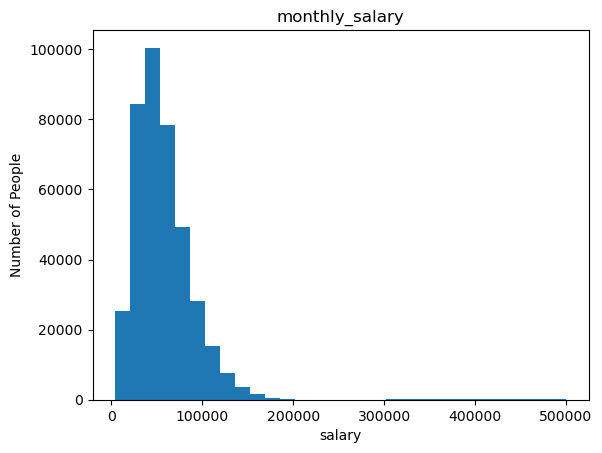

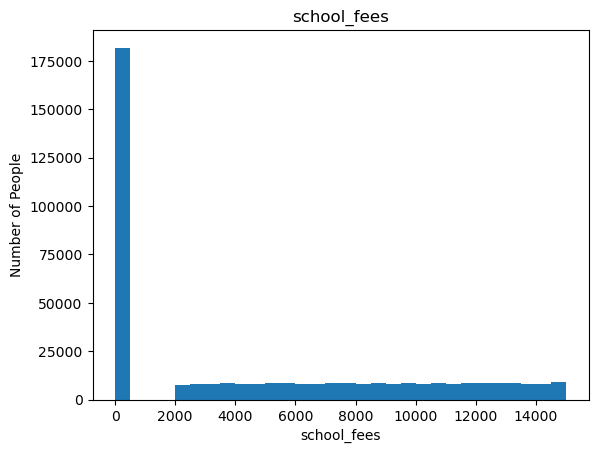

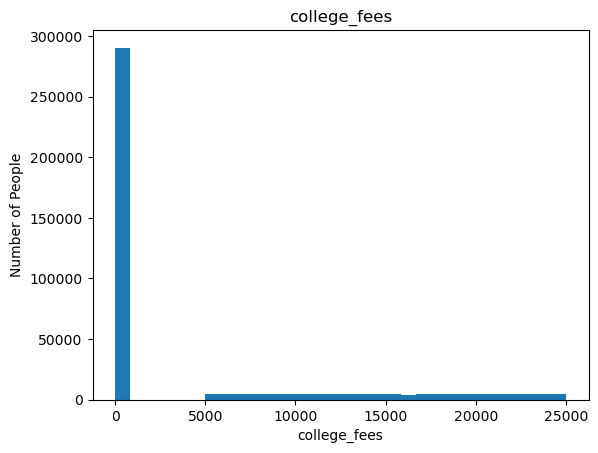

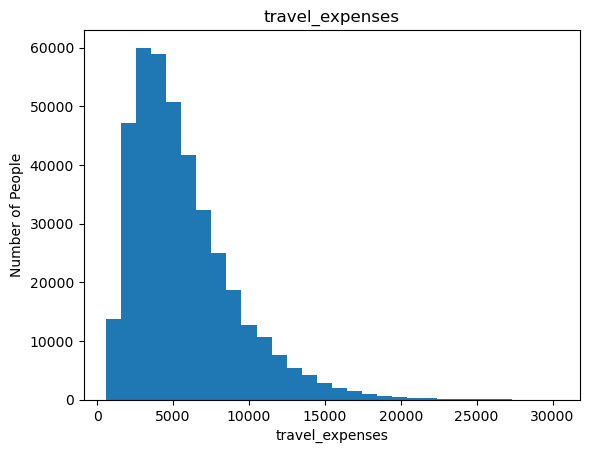

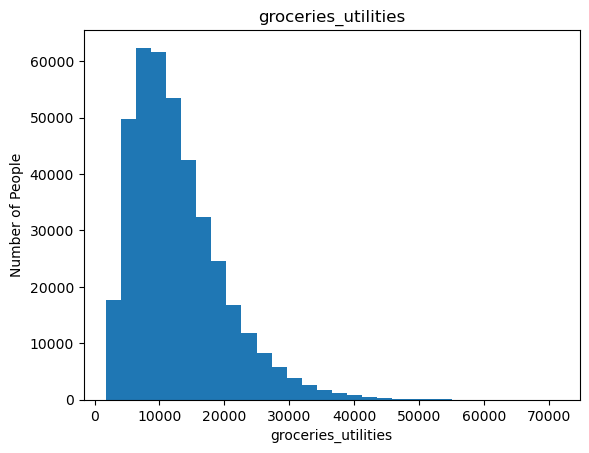

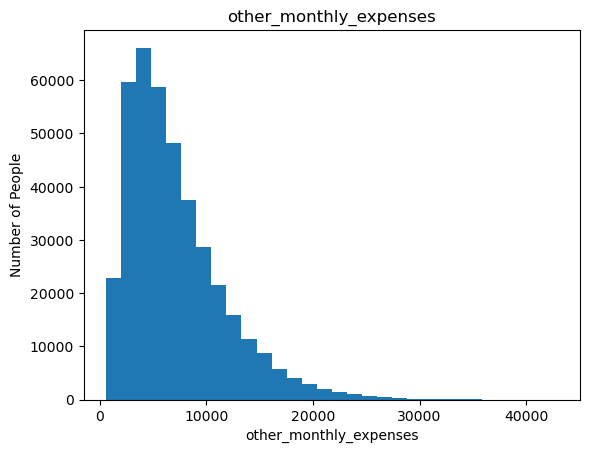

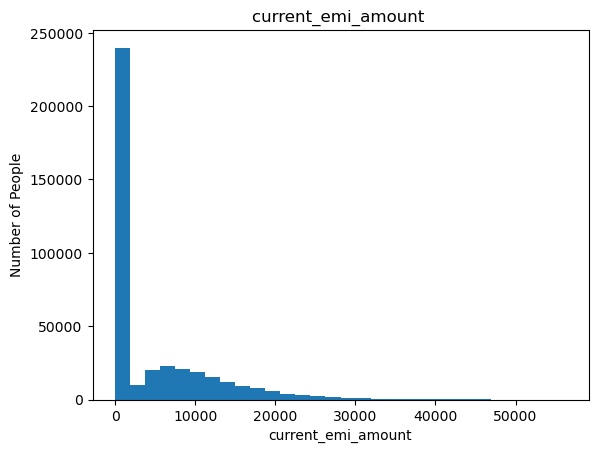

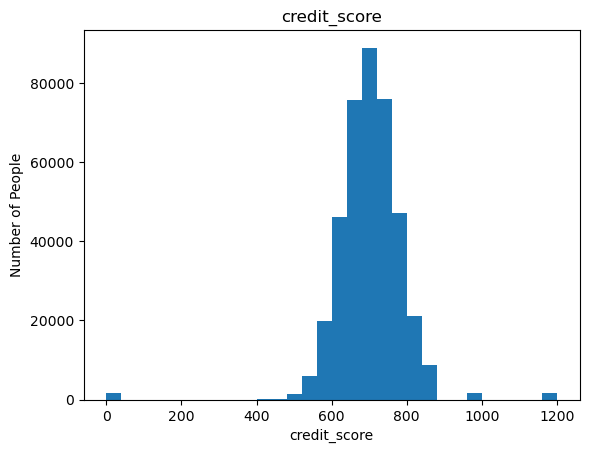

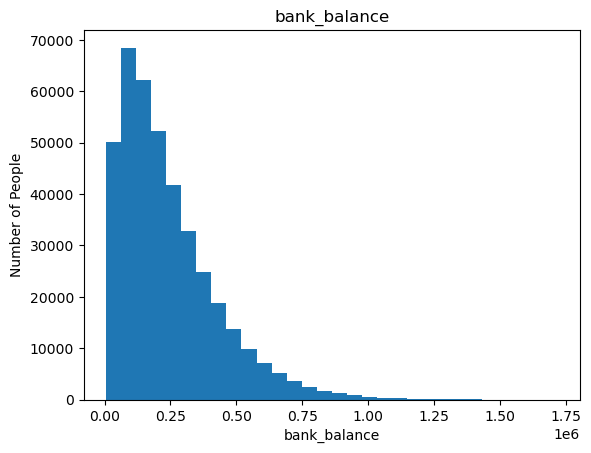

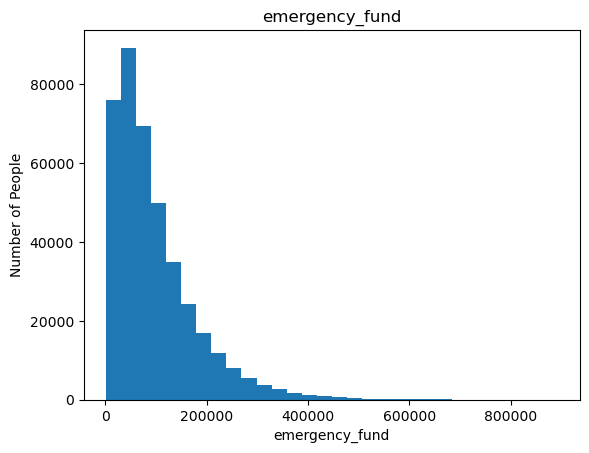

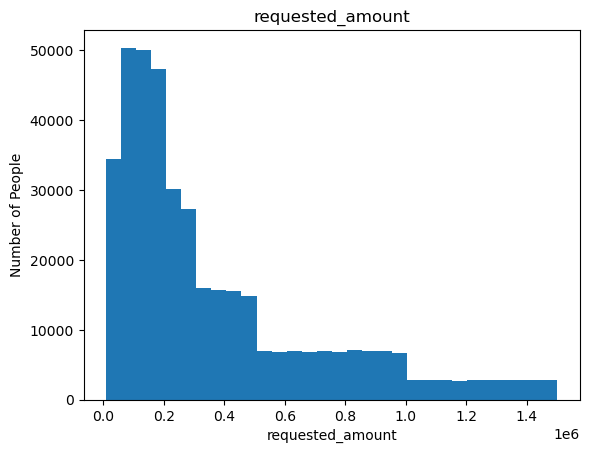

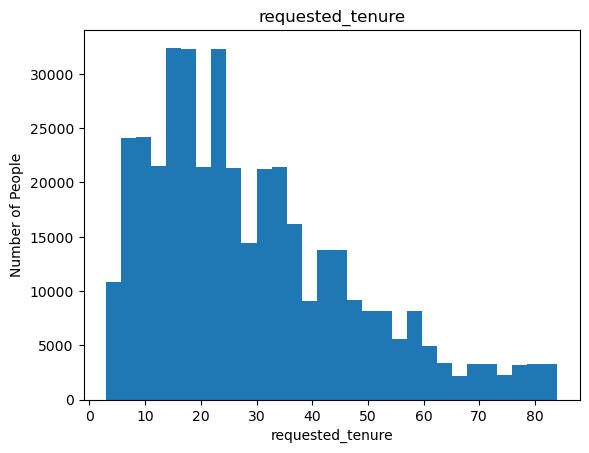

In [115]:
plt.hist(data=df,x="monthly_salary",bins=30)
plt.xlabel("salary")
plt.ylabel("Number of People")
plt.title("monthly_salary")
plt.show()

plt.hist(data=df,x="school_fees",bins=30)
plt.xlabel("school_fees")
plt.ylabel("Number of People")
plt.title("school_fees")
plt.show()

plt.hist(data=df,x="college_fees",bins=30)
plt.xlabel("college_fees")
plt.ylabel("Number of People")
plt.title("college_fees")
plt.show()

plt.hist(data=df,x="travel_expenses",bins=30)
plt.xlabel("travel_expenses")
plt.ylabel("Number of People")
plt.title("travel_expenses")
plt.show()

plt.hist(data=df,x="groceries_utilities",bins=30)
plt.xlabel("groceries_utilities")
plt.ylabel("Number of People")
plt.title("groceries_utilities")
plt.show()

plt.hist(data=df,x="other_monthly_expenses",bins=30)
plt.xlabel("other_monthly_expenses")
plt.ylabel("Number of People")
plt.title("other_monthly_expenses")
plt.show()


plt.hist(data=df,x="current_emi_amount",bins=30)
plt.xlabel("current_emi_amount")
plt.ylabel("Number of People")
plt.title("current_emi_amount ")
plt.show()

plt.hist(data=df,x="credit_score",bins=30)
plt.xlabel("credit_score")
plt.ylabel("Number of People")
plt.title("credit_score")
plt.show()

plt.hist(data=df,x="bank_balance",bins=30)
plt.xlabel("bank_balance")
plt.ylabel("Number of People")
plt.title("bank_balance")
plt.show()

plt.hist(data=df,x="emergency_fund",bins=30)
plt.xlabel("emergency_fund")
plt.ylabel("Number of People")
plt.title("emergency_fund")
plt.show()


plt.hist(data=df,x="requested_amount",bins=30)
plt.xlabel("requested_amount")
plt.ylabel("Number of People")
plt.title("requested_amount")
plt.show()



plt.hist(data=df,x="requested_tenure",bins=30)
plt.xlabel("requested_tenure")
plt.ylabel("Number of People")
plt.title("requested_tenure")
plt.show()

In [116]:
corr = df.corr(numeric_only=True)

corr["max_monthly_emi"].sort_values(ascending=False)

max_monthly_emi             1.000000
groceries_utilities         0.485398
bank_balance                0.458856
travel_expenses             0.441654
emergency_fund              0.415685
other_monthly_expenses      0.382509
monthly_salary              0.379245
credit_score                0.229474
suspicious_salary           0.129562
years_of_employment         0.028977
rent_outlier                0.012384
requested_tenure            0.000879
high_salary_low_exp         0.000118
salary_anomaly              0.000118
late_high_salary_low_exp    0.000022
age                        -0.000732
requested_amount           -0.001857
family_size                -0.062136
dependents                 -0.062136
expense_to_income_ratio    -0.124874
high_financial_stress      -0.146782
monthly_rent               -0.170564
school_fees                -0.215049
current_emi_amount         -0.242237
college_fees               -0.258599
rent_to_salary_ratio       -0.262242
family_mismatch                  NaN
e

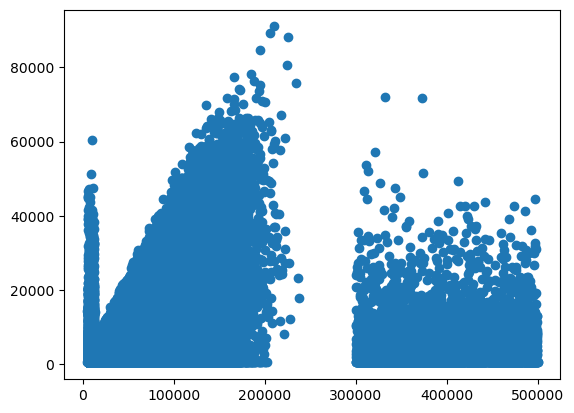

In [117]:
plt.scatter(df["monthly_salary"], df["max_monthly_emi"])
plt.show()

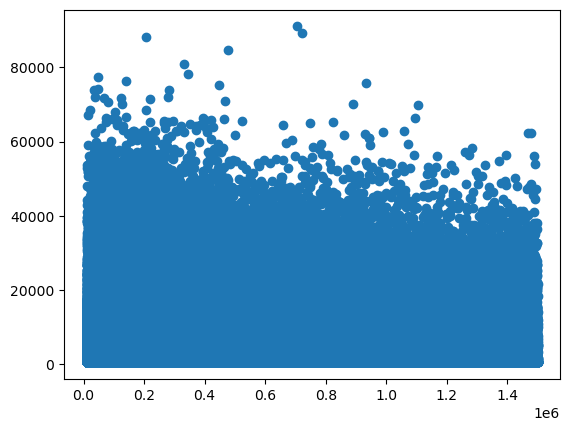

In [118]:
plt.scatter(df["requested_amount"], df["max_monthly_emi"])
plt.show()

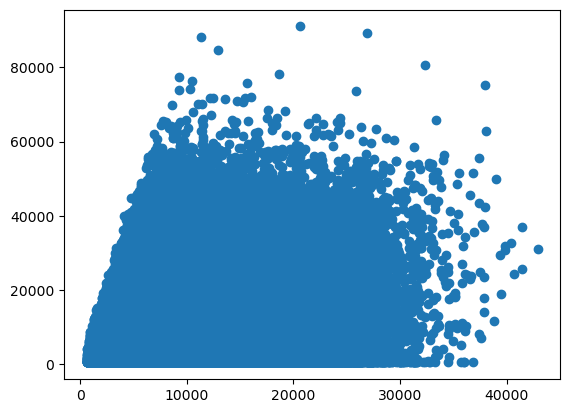

In [119]:
plt.scatter(df["other_monthly_expenses"], df["max_monthly_emi"])
plt.show()

Final data check

In [120]:
df["max_monthly_emi"].describe()
df["max_monthly_emi"].isnull().sum()

np.int64(0)

In [121]:
df[df["strong_error"]]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,suspicious_salary,salary_anomaly,family_mismatch,expense_mismatch,high_salary_low_exp,late_high_salary_low_exp,strong_error,rent_outlier,strong_rent_error,rent_to_salary_ratio,expense_to_income_ratio,high_financial_stress


In [122]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

family_mismatch
expense_mismatch
strong_error
strong_rent_error


In [123]:
df.drop(columns=[
    "family_mismatch",
    "expense_mismatch",
    "strong_error",
    "strong_rent_error"
], inplace=True)

In [124]:
df["monthly_rent"].fillna(0, inplace=True)

df["no_credit_history"] = df["credit_score"].isnull().astype(int)
df["credit_score"].fillna(0, inplace=True)

C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_21312\582208718.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["monthly_rent"].fillna(0, inplace=True)
C:\Users\Rukshana Afrin A\AppData\Local\Temp\ipykernel_21312\582208718.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [125]:
drop_age = df[df["age"].isnull()].index
df.drop(index=drop_age, inplace=True)

In [126]:
df["total_expenses"] = (
    df["travel_expenses"] +
    df["groceries_utilities"] +
    df["other_monthly_expenses"] +
    df["monthly_rent"] +
    df["school_fees"] +
    df["college_fees"]
)

In [127]:
df["expense_to_income_ratio"] = df["total_expenses"] / df["monthly_salary"]
df["rent_to_salary_ratio"] = df["monthly_rent"] / df["monthly_salary"]
df["emi_to_income_ratio"] = df["current_emi_amount"] / df["monthly_salary"]

In [128]:
df.replace([np.inf, -np.inf], 0, inplace=True)

In [129]:
df["rent_to_salary_ratio"] = df["rent_to_salary_ratio"].fillna(0)
df["expense_to_income_ratio"] = df["expense_to_income_ratio"].fillna(0)
df["expense_to_income_ratio"]=df["emi_to_income_ratio"].fillna(0)

In [130]:
df["has_rent"] = (df["monthly_rent"] > 0).astype(int)

In [131]:
df_reg = df.copy()
df_clf = df.copy()

In [132]:
leakage_cols = [
    "emi_to_income_ratio",
    "current_emi_amount",
    "emi_eligibility"
]

Split the data into training and test

In [133]:
X_reg = df_reg.drop(columns=["max_monthly_emi"] + leakage_cols)
y_reg = df_reg["max_monthly_emi"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [134]:
cat_cols = X_train_reg.select_dtypes(include="object").columns

In [135]:
cat_cols

Index(['gender', 'marital_status', 'education', 'employment_type',
       'company_type', 'house_type', 'existing_loans', 'emi_scenario'],
      dtype='object')

In [136]:
# Encoding
X_train_reg_enc = pd.get_dummies(X_train_reg, columns=cat_cols, drop_first=False)
X_test_reg_enc = pd.get_dummies(X_test_reg, columns=cat_cols, drop_first=False)

# Align
X_train_reg_enc, X_test_reg_enc = X_train_reg_enc.align(
    X_test_reg_enc,
    join='left',
    axis=1,
    fill_value=0
)

In [404]:
pickle.dump(X_train_reg_enc.columns, open("columns_reg.pkl", "wb"))

In [137]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reg_enc)   # learn from train
X_test_scaled = scaler.transform(X_test_reg_enc)         # apply same on test

In [406]:
import mlflow

mlflow.set_tracking_uri("file:///C:/mlruns")
mlflow.set_experiment("EMI_Project")

with mlflow.start_run(run_name="TEST_RUN"):
    mlflow.log_param("test_param", 123)
    mlflow.log_metric("test_metric", 0.99)

print("RUN CREATED")

RUN CREATED


In [407]:
with mlflow.start_run(run_name="Linear_Regression"):

  lr=LinearRegression()

  lr.fit(X_train_scaled,y_train_reg)

  preds = lr.predict(X_test_scaled)

  rmse = np.sqrt(mean_squared_error(y_test_reg, preds))

  r2 = r2_score(y_test_reg, preds)

  mlflow.log_param("model","LinearRegression")
  mlflow.log_metric("rmse",rmse)
  mlflow.log_metric("r2_score",r2)

  mlflow.sklearn.log_model(lr,name="linear_model")
  

2026/03/29 20:09:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [408]:

with mlflow.start_run(run_name="Ridge_Polynomial"):

    # Step 1: Polynomial Features
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # Step 2: Ridge Model
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_poly, y_train_reg)

    # Step 3: Predictions
    preds = ridge.predict(X_test_poly)

    # Step 4: Metrics
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2 = r2_score(y_test_reg, preds)

    # Step 5: Log to MLflow
    mlflow.log_param("model", "Ridge_Polynomial")
    mlflow.log_param("alpha", 1.0)
    mlflow.log_param("degree", 2)

    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_score", r2)

    # Step 6: Log model
    mlflow.sklearn.log_model(ridge, name="ridge_poly_model")

print("Ridge Polynomial run logged!")

2026/03/29 20:10:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge Polynomial run logged!


In [409]:
with mlflow.start_run(run_name="Lasso_Polynomial"):

    # Step 1: Model
    lasso = Lasso(alpha=0.1)
    lasso.fit(X_train_poly, y_train_reg)

    # Step 2: Predictions
    preds_lasso = lasso.predict(X_test_poly)

    # Step 3: Metrics
    rmse_lasso = np.sqrt(mean_squared_error(y_test_reg, preds_lasso))
    r2_lasso = r2_score(y_test_reg, preds_lasso)

    # Step 4: Log params
    mlflow.log_param("model", "Lasso_Polynomial")
    mlflow.log_param("alpha", 0.1)
    mlflow.log_param("degree", 2)

    # Step 5: Log metrics
    mlflow.log_metric("rmse", rmse_lasso)
    mlflow.log_metric("r2_score", r2_lasso)

    # Step 6: Log model
    mlflow.sklearn.log_model(lasso, name="lasso_poly_model")

print("Lasso Polynomial run logged!")

c:\Users\Rukshana Afrin A\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.827e+11, tolerance: 1.909e+09
  model = cd_fast.enet_coordinate_descent(
2026/03/29 20:14:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso Polynomial run logged!


In [410]:
with mlflow.start_run(run_name="RandomForest_Baseline"):

    rf_reg = RandomForestRegressor(random_state=42)
    rf_reg.fit(X_train_reg_enc, y_train_reg)

    preds_rf = rf_reg.predict(X_test_reg_enc)

    rmse_rf = np.sqrt(mean_squared_error(y_test_reg, preds_rf))
    r2_rf = r2_score(y_test_reg, preds_rf)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("type", "baseline")

    mlflow.log_metric("rmse", rmse_rf)
    mlflow.log_metric("r2_score", r2_rf)

    mlflow.sklearn.log_model(rf_reg, name="rf_baseline_model")

print("RF baseline logged!")
print("RMSE",rmse_rf)
print("r2_rf",r2_rf)


2026/03/29 20:25:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF baseline logged!
RMSE 1018.0210201752468
r2_rf 0.9827492360995397


In [411]:
train_preds = rf_reg.predict(X_train_reg_enc)

train_r2 = r2_score(y_train_reg, train_preds)
test_r2 = r2_score(y_test_reg, preds_rf)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9974499706495212
Test R2: 0.9827492360995397


In [412]:
feature_importance = pd.Series(rf_reg.feature_importances_, index=X_train_reg_enc.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(20))

monthly_salary                0.387301
total_expenses                0.129479
house_type_rented             0.117626
expense_to_income_ratio       0.081650
existing_loans_no             0.064125
existing_loans_yes            0.053076
college_fees                  0.037206
credit_score                  0.031216
groceries_utilities           0.023518
school_fees                   0.022865
bank_balance                  0.020912
years_of_employment           0.006288
high_financial_stress         0.005854
rent_to_salary_ratio          0.004256
emergency_fund                0.002291
other_monthly_expenses        0.001816
travel_expenses               0.001658
employment_type_government    0.001439
monthly_rent                  0.001081
requested_amount              0.001021
dtype: float64


In [413]:
with mlflow.start_run(run_name="XGBoost_Baseline"):

    xgb_reg = XGBRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    )

    xgb_reg.fit(X_train_reg_enc, y_train_reg)

    preds_xgb = xgb_reg.predict(X_test_reg_enc)

    rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, preds_xgb))
    r2_xgb = r2_score(y_test_reg, preds_xgb)

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("type", "baseline")

    mlflow.log_metric("rmse", rmse_xgb)
    mlflow.log_metric("r2_score", r2_xgb)

    mlflow.xgboost.log_model(xgb_reg, name="xgb_baseline_model")

print("XGBoost baseline logged!")

XGBoost baseline logged!


In [414]:
results = {
    "Linear Regression": 0.72,
    "Ridge": 0.90,
    "Lasso": 0.90,
    "Random Forest": 0.983,
    "XGBoost": 0.980
}

print(results)

{'Linear Regression': 0.72, 'Ridge': 0.9, 'Lasso': 0.9, 'Random Forest': 0.983, 'XGBoost': 0.98}


In [415]:
print("Train R2:", rf_reg.score(X_train_reg_enc, y_train_reg))
print("Test R2:", rf_reg.score(X_test_reg_enc, y_test_reg))

Train R2: 0.9974499706495212
Test R2: 0.9827492360995397


In [416]:
print("Train R2:", xgb_reg.score(X_train_reg_enc, y_train_reg))
print("Test R2:", xgb_reg.score(X_test_reg_enc, y_test_reg))

Train R2: 0.9813656682836193
Test R2: 0.9787892842138898


In [180]:
print("Train R2:", xgb_reg.score(X_train_reg_enc, y_train_reg))
print("Test R2:", xgb_reg.score(X_test_reg_enc, y_test_reg))

Train R2: 0.9843089180232693
Test R2: 0.9823771611193663


# Target for classification

In [417]:
leakage_cols = [
    "max_monthly_emi",
    "emi_to_income_ratio",
    "current_emi_amount"
]

X_clf = df_clf.drop(columns=["emi_eligibility"] + leakage_cols)
y_clf = df_clf["emi_eligibility"]


In [418]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

In [419]:
cat_cols = X_train.select_dtypes(include="object").columns

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [420]:
pickle.dump(X_train.columns, open("columns_clf.pkl", "wb"))

In [421]:
scaler_clf = StandardScaler()

X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

In [422]:


le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [423]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [216]:
with mlflow.start_run(run_name="Logistic_Classification"):

    # Model
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_res, y_train_res)

    # Predictions
    preds = clf.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")
    precision = precision_score(y_test, preds, average="weighted")
    recall = recall_score(y_test, preds, average="weighted")

    # Log params
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("smote_used", True)

    # Log metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)

    # Log model
    mlflow.sklearn.log_model(clf, name="logistic_model")

print("Classification run logged!")

2026/03/26 15:40:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Classification run logged!


In [217]:
with mlflow.start_run(run_name="RF_Classification"):

    # Model
    rf_clf = RandomForestClassifier(random_state=42)
    rf_clf.fit(X_train_res, y_train_res)

    # Predictions
    preds_rf = rf_clf.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, preds_rf)
    f1 = f1_score(y_test, preds_rf, average="weighted")
    precision = precision_score(y_test, preds_rf, average="weighted")
    recall = recall_score(y_test, preds_rf, average="weighted")

    # Log params
    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("type", "baseline")
    mlflow.log_param("smote_used", True)

    # Log metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)

    # Log model
    mlflow.sklearn.log_model(rf_clf, name="rf_classifier_model")

print("RF classification logged!")

2026/03/26 15:47:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF classification logged!


In [138]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 12, 15],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}

with mlflow.start_run(run_name="RandomForest_Tuned"):

    # RandomizedSearch
    rf = RandomForestRegressor(random_state=42)
    random_search = RandomizedSearchCV(
        rf, param_dist,
        n_iter=30, cv=5,
        scoring='r2',
        n_jobs=-1, verbose=1,
        random_state=42
    )
    random_search.fit(X_train_reg_enc, y_train_reg)

    # Best model
    rf_reg = random_search.best_estimator_

    preds_rf = rf_reg.predict(X_test_reg_enc)
    rmse_rf = np.sqrt(mean_squared_error(y_test_reg, preds_rf))
    r2_rf   = r2_score(y_test_reg, preds_rf)

    # Log best params automatically
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("rmse", rmse_rf)
    mlflow.log_metric("r2_score", r2_rf)
    mlflow.sklearn.log_model(rf_reg, name="rf_tuned_model")

    print("Best Params:", random_search.best_params_)
    print("RMSE:", rmse_rf)
    print("r2_rf:", r2_rf)

    # Check overfitting
    train_r2 = rf_reg.score(X_train_reg_enc, y_train_reg)
    print("Train R2:", train_r2)
    print("Test R2:", r2_rf)
    print("Gap:", round(train_r2 - r2_rf, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026/04/04 00:09:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 15}
RMSE: 1305.1972353538345
r2_rf: 0.9716438587621772
Train R2: 0.9802121137755323
Test R2: 0.9716438587621772
Gap: 0.0086


In [139]:
import joblib
joblib.dump(rf_reg, "model_reg.pkl", compress=3)

['model_reg.pkl']

In [433]:
with mlflow.start_run(run_name="XGB_Classification"):

    xgb_clf = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )

    xgb_clf.fit(X_train_res, y_train_res)

    preds_xgb = xgb_clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds_xgb)
    f1 = f1_score(y_test, preds_xgb, average="weighted")
    precision = precision_score(y_test, preds_xgb, average="weighted")
    recall = recall_score(y_test, preds_xgb, average="weighted")

    mlflow.log_param("model", "XGBoostClassifier")
    mlflow.log_param("type", "baseline")
    mlflow.log_param("smote_used", True)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)

    mlflow.xgboost.log_model(xgb_clf, name="xgb_classifier_model")

print("XGB classification logged!")


XGB classification logged!


In [434]:
print("accuracy", acc)
print("f1_score", f1)
print("precision", precision)
print("recall", recall)

accuracy 0.9379260133311575
f1_score 0.9377424763680923
precision 0.9377839940716504
recall 0.9379260133311575


In [435]:
"""rf_clf = RandomForestClassifier(random_state=42)

rf_clf.fit(X_train_res, y_train_res)

preds_rf = rf_clf.predict(X_test_scaled)

print(classification_report(y_test, preds_rf))"""

'rf_clf = RandomForestClassifier(random_state=42)\n\nrf_clf.fit(X_train_res, y_train_res)\n\npreds_rf = rf_clf.predict(X_test_scaled)\n\nprint(classification_report(y_test, preds_rf))'

In [436]:

"""xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    scale_pos_weight=2
)

xgb_clf.fit(X_train_res, y_train_res)

preds_xgb = xgb_clf.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, preds_xgb))"""

'xgb_clf = XGBClassifier(\n    n_estimators=200,\n    learning_rate=0.1,\n    max_depth=6,\n    random_state=42,\n    scale_pos_weight=2\n)\n\nxgb_clf.fit(X_train_res, y_train_res)\n\npreds_xgb = xgb_clf.predict(X_test_scaled)\n\nfrom sklearn.metrics import classification_report\nprint(classification_report(y_test, preds_xgb))'

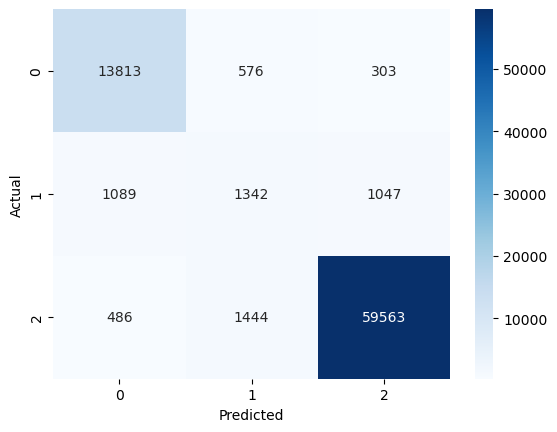

In [437]:
cm = confusion_matrix(y_test, preds_xgb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd
print(pd.Series(y_train_res).value_counts())
print(le.classes_)

2    246403
0    246403
1    246403
Name: count, dtype: int64
['Eligible' 'High_Risk' 'Not_Eligible']


In [439]:
print(df['emi_eligibility'].value_counts())

emi_eligibility
Not_Eligible    307896
Eligible         73220
High_Risk        17198
Name: count, dtype: int64


In [442]:
# FINAL MODEL SELECTION

best_reg_model = rf_reg     
best_clf_model = xgb_clf

In [ ]:


pickle.dump(best_clf_model, open("model_clf.pkl", "wb"))
pickle.dump(best_reg_model, open("model_reg.pkl", "wb"))

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(scaler_clf, open("scaler_clf.pkl", "wb"))

pickle.dump(X_train_reg_enc.columns, open("columns_reg.pkl", "wb"))
pickle.dump(X_train.columns, open("columns_clf.pkl", "wb"))

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)